# Write Linear, Read Nonlinear Experiment

**Motivation**: We discovered that bias-free ReLU encoders are positively homogeneous: f(t·x) = t·f(x). This means deep bias-free encoders collapse to effectively a single linear projection — multiple layers don't add representational power.

**Question**: Is a linear encoder with a nonlinear decoder sufficient for good autoencoder performance?

**Hypothesis**: If the encoder's job is primarily to select which features matter (a projection), while the decoder does the heavy lifting of reconstruction, then "write linear + read nonlinear" might perform as well as "write nonlinear + read nonlinear".

## Architectures Compared

| Name | Encoder | Decoder |
|------|---------|--------|
| `WriteLinear` | Linear(n→m, no bias) | l layers with ReLU + biases |
| `FullyNonlinear` | l layers with ReLU + biases | l layers with ReLU + biases |

## Contents

1. **Primary Results: Test Loss** — Decoder-depth matched & parameter-matched comparisons
2. **Secondary Metrics** — Train MSE, generalization gap, per-feature MSE, convergence
3. **Nonlinearity Metrics** — Feature trajectories, arc/chord, linearity scores, gradient analysis
4. **Other Metrics** — Latent utilization, effective dimensionality
5. **Summary** — Key findings and interpretation

## Future Integration

This notebook currently runs as a standalone comparison. Eventually these comparisons
should be part of a unified analysis suite where you train a single model and run 
multiple ablations against it, avoiding redundant training.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from typing import List, Dict, Tuple
from scipy import stats
import torch.autograd.functional as AF

# Import from core module
from core import (
    device, 
    generate_sparse_data, 
    Autoencoder,
    compute_feature_geometry
)

print(f"Using device: {device}")

Using device: cpu


## WriteLinearAutoencoder Architecture

Linear encoder (single projection) + deep nonlinear decoder.

In [2]:
class WriteLinearAutoencoder(nn.Module):
    """
    Autoencoder with linear encoder and deep nonlinear decoder.
    
    Encoder: Linear(n→m, no bias)
    Decoder: l layers of [Linear + ReLU] with biases
    
    The encoder is a single linear projection (positive homogeneity built-in).
    All nonlinearity is in the decoder.
    """
    def __init__(self, n: int, m: int, decoder_layers: int = 2):
        """
        Args:
            n: feature dimension (input/output width)
            m: bottleneck dimension
            decoder_layers: number of layers in decoder (l in the baseline)
        """
        super().__init__()
        self.n = n
        self.m = m
        self.decoder_layers = decoder_layers
        
        # Linear encoder: n → m, no bias (positively homogeneous)
        self.encoder = nn.Linear(n, m, bias=False)
        
        # Deep nonlinear decoder: m → n with l layers
        # Structure: Linear(m→n) → ReLU → [Linear(n→n) → ReLU] × (l-1)
        decoder_parts = []
        decoder_parts.append(nn.Linear(m, n, bias=True))
        for _ in range(decoder_layers - 1):
            decoder_parts.append(nn.ReLU())
            decoder_parts.append(nn.Linear(n, n, bias=True))
        decoder_parts.append(nn.ReLU())  # Final ReLU for non-negative output
        self.decoder = nn.Sequential(*decoder_parts)
    
    def encode(self, x):
        return self.encoder(x)
    
    def decode(self, z):
        return self.decoder(z)
    
    def forward(self, x):
        z = self.encode(x)
        return self.decode(z), z


def count_parameters(model):
    """Count total trainable parameters."""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


# Test instantiation and parameter counts
print("Parameter counts:")
print("=" * 50)
for l_test in [2, 3, 4]:
    model_wl = WriteLinearAutoencoder(n=5, m=2, decoder_layers=l_test)
    model_fn = Autoencoder(n=5, m=2, l=l_test, tied_weights=False)
    print(f"l={l_test}: WriteLinear={count_parameters(model_wl)}, FullyNonlinear={count_parameters(model_fn)}")

Parameter counts:
l=2: WriteLinear=55, FullyNonlinear=87
l=3: WriteLinear=85, FullyNonlinear=147
l=4: WriteLinear=115, FullyNonlinear=207


## Metric Functions

Functions to compute all nonlinearity and auxiliary metrics.

In [3]:
def compute_latent_utilization(model, n_samples: int = 5000, S: float = 0.9) -> Dict:
    """
    Compute latent space utilization metrics.
    
    Returns:
        variance_per_dim: variance of each latent dimension
        effective_dim: effective dimensionality (exp entropy of normalized variances)
    """
    model.eval()
    with torch.no_grad():
        x = generate_sparse_data(n_samples, model.n, S)
        z = model.encode(x)
        
        # Variance per dimension
        var_per_dim = z.var(dim=0).cpu().numpy()
        
        # Effective dimensionality: exp(entropy of normalized variances)
        var_normalized = var_per_dim / (var_per_dim.sum() + 1e-10)
        entropy = -np.sum(var_normalized * np.log(var_normalized + 1e-10))
        effective_dim = np.exp(entropy)
        
    return {
        'variance_per_dim': var_per_dim,
        'effective_dim': effective_dim,
        'total_variance': var_per_dim.sum()
    }


def compute_per_feature_mse(model, n_samples: int = 5000, S: float = 0.9) -> np.ndarray:
    """
    Compute MSE broken down by feature.
    
    Returns:
        Array of shape (n,) with MSE for each feature
    """
    model.eval()
    with torch.no_grad():
        x = generate_sparse_data(n_samples, model.n, S)
        x_recon, _ = model(x)
        per_feature_mse = ((x - x_recon) ** 2).mean(dim=0).cpu().numpy()
    return per_feature_mse


def compute_convergence_speed(losses: List[float], threshold_pct: float = 0.9) -> int:
    """
    Compute steps to reach threshold_pct of final loss improvement.
    
    Returns:
        Number of steps to reach 90% of final improvement (from initial to final loss)
    """
    initial_loss = np.mean(losses[:10])
    final_loss = np.mean(losses[-100:])
    target_loss = initial_loss - threshold_pct * (initial_loss - final_loss)
    
    for step, loss in enumerate(losses):
        if loss <= target_loss:
            return step
    return len(losses)  # Never reached


def compute_linearity_score(inputs: torch.Tensor, outputs: torch.Tensor) -> float:
    """
    Compute R² of best linear fit from inputs to outputs.
    
    Returns:
        R² score (1.0 = perfectly linear, 0.0 = no linear relationship)
    """
    with torch.no_grad():
        # Add bias term
        inputs_with_bias = torch.cat([inputs, torch.ones(inputs.shape[0], 1, device=inputs.device)], dim=1)
        
        # Least squares fit
        W = torch.linalg.lstsq(inputs_with_bias, outputs).solution
        outputs_linear = inputs_with_bias @ W
        
        # R² = 1 - SS_res / SS_tot
        ss_res = ((outputs - outputs_linear) ** 2).sum()
        ss_tot = ((outputs - outputs.mean(dim=0)) ** 2).sum()
        
        r2 = (1 - ss_res / (ss_tot + 1e-10)).item()
    return max(0.0, r2)  # Clamp to [0, 1]


def compute_nonlinear_gain(mse_full: float, mse_baseline: float) -> float:
    """
    Compute relative improvement of full model over baseline.
    
    Returns:
        (mse_baseline - mse_full) / mse_baseline
        Positive = model beats baseline, 0 = no benefit
    """
    if mse_baseline < 1e-10:
        return 0.0
    return (mse_baseline - mse_full) / mse_baseline


def compute_finite_diff_curvature(func, inputs: torch.Tensor, output_dim: int,
                                   h_values: List[float] = [0.01, 0.05, 0.1]) -> Dict[str, float]:
    """
    Compute numerical curvature using finite differences.
    
    ReLU networks are piecewise linear, so Hessian = 0 almost everywhere.
    Instead, we measure curvature by how much the function deviates from linear
    over a finite scale h:
    
        curvature = ||f(x+h·d) - 2·f(x) + f(x-h·d)|| / h²
    
    Inside a linear region: curvature ≈ 0
    When perturbation crosses a ReLU boundary: curvature > 0
    
    Returns:
        Dict with curvature for each h value
    """
    n_samples = min(inputs.shape[0], 50)
    input_dim = inputs.shape[1]
    results = {f'curvature_h{h}': [] for h in h_values}
    
    with torch.no_grad():
        for i in range(n_samples):
            x = inputs[i:i+1]
            f_center = func(x)
            
            # Average over random directions
            for _ in range(10):
                d = torch.randn(1, input_dim, device=x.device)
                d = d / d.norm()  # Unit direction
                
                for h in h_values:
                    f_plus = func(x + h * d)
                    f_minus = func(x - h * d)
                    # Second-order finite difference
                    curvature = (f_plus - 2 * f_center + f_minus) / (h ** 2)
                    results[f'curvature_h{h}'].append(curvature.norm().item())
    
    return {k: np.mean(v) for k, v in results.items()}


def train_linear_baseline(n: int, m: int, n_steps: int = 5000, S: float = 0.9,
                          batch_size: int = 1024, lr: float = 1e-3) -> float:
    """
    Train a linear autoencoder (l=1) as baseline and return its test MSE.
    
    Uses Autoencoder(n, m, l=1, tied_weights=False) which gives:
    - Encoder: Linear(n→m), no activation
    - Decoder: Linear(m→n) → ReLU
    
    This is "linear read + linear write" with final ReLU for non-negativity,
    matching the Toy Models of Superposition setup.
    
    Returns:
        Test MSE of the trained linear autoencoder
    """
    model = Autoencoder(n, m, l=1, tied_weights=False).to(device)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-2)
    
    for _ in range(n_steps):
        x = generate_sparse_data(batch_size, n, S)
        x_recon, _ = model(x)
        loss = nn.functional.mse_loss(x_recon, x)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
    # Evaluate on test data
    model.eval()
    with torch.no_grad():
        x_test = generate_sparse_data(10000, n, S)
        x_recon, _ = model(x_test)
        test_mse = nn.functional.mse_loss(x_recon, x_test).item()
    
    return test_mse


def compute_all_nonlinearity_metrics(model, n_samples: int = 1000, S: float = 0.9,
                                      mse_linear_ae: float = None) -> Dict:
    """
    Compute all nonlinearity metrics for encoder, decoder, and full model.
    
    Args:
        model: The autoencoder model to analyze
        n_samples: Number of samples for evaluation
        S: Sparsity parameter
        mse_linear_ae: MSE of a trained linear autoencoder (for full_nonlinear_gain).
                       If None, full_nonlinear_gain will be set to None.
    
    Returns dict with:
        - encoder_linearity, decoder_linearity, full_linearity (R² scores)
        - encoder_nonlinear_gain, decoder_nonlinear_gain (vs linear approximations)
        - full_nonlinear_gain (vs trained linear AE - the meaningful comparison)
        - encoder_curvature_*, decoder_curvature_*, full_curvature_* (finite diff curvature)
        - mse_full, mse_linear_enc, mse_linear_dec
    """
    model.eval()
    
    with torch.no_grad():
        x = generate_sparse_data(n_samples, model.n, S)
        z = model.encode(x)
        x_recon, _ = model(x)
    
    # Linearity scores
    encoder_linearity = compute_linearity_score(x, z)
    decoder_linearity = compute_linearity_score(z, x_recon)
    full_linearity = compute_linearity_score(x, x_recon)
    
    # MSE with linear approximations
    with torch.no_grad():
        # Linear encoder approximation: keep nonlinear decoder, replace encoder with linear fit
        x_with_bias = torch.cat([x, torch.ones(n_samples, 1, device=device)], dim=1)
        W_enc = torch.linalg.lstsq(x_with_bias, z).solution
        z_linear = x_with_bias @ W_enc
        x_recon_linear_enc = model.decode(z_linear)
        mse_linear_enc = nn.functional.mse_loss(x_recon_linear_enc, x).item()
        
        # Linear decoder approximation: keep nonlinear encoder, replace decoder with linear fit
        z_with_bias = torch.cat([z, torch.ones(n_samples, 1, device=device)], dim=1)
        W_dec = torch.linalg.lstsq(z_with_bias, x).solution
        x_recon_linear_dec = z_with_bias @ W_dec
        mse_linear_dec = nn.functional.mse_loss(x_recon_linear_dec, x).item()
        
        mse_full = nn.functional.mse_loss(x_recon, x).item()
    
    # Nonlinear gains for encoder and decoder (vs linear approximations)
    encoder_nonlinear_gain = compute_nonlinear_gain(mse_full, mse_linear_enc)
    decoder_nonlinear_gain = compute_nonlinear_gain(mse_full, mse_linear_dec)
    
    # Full nonlinear gain: compare to trained linear autoencoder
    if mse_linear_ae is not None:
        full_nonlinear_gain = compute_nonlinear_gain(mse_full, mse_linear_ae)
    else:
        full_nonlinear_gain = None
    
    # Finite difference curvature (replaces Hessian which is 0 for ReLU networks)
    x_small = generate_sparse_data(50, model.n, S)
    z_small = model.encode(x_small)
    
    encoder_curvature = compute_finite_diff_curvature(model.encode, x_small, model.m)
    decoder_curvature = compute_finite_diff_curvature(model.decode, z_small, model.n)
    
    def full_model_func(inp):
        return model(inp)[0]
    full_curvature = compute_finite_diff_curvature(full_model_func, x_small, model.n)
    
    return {
        'encoder_linearity': encoder_linearity,
        'decoder_linearity': decoder_linearity,
        'full_linearity': full_linearity,
        'encoder_nonlinear_gain': encoder_nonlinear_gain,
        'decoder_nonlinear_gain': decoder_nonlinear_gain,
        'full_nonlinear_gain': full_nonlinear_gain,
        # Curvature metrics (using h=0.05 as primary)
        'encoder_curvature': encoder_curvature.get('curvature_h0.05', 0.0),
        'decoder_curvature': decoder_curvature.get('curvature_h0.05', 0.0),
        'full_curvature': full_curvature.get('curvature_h0.05', 0.0),
        # All curvature values for analysis
        'encoder_curvature_all': encoder_curvature,
        'decoder_curvature_all': decoder_curvature,
        'full_curvature_all': full_curvature,
        # Raw MSE values
        'mse_full': mse_full,
        'mse_linear_enc': mse_linear_enc,
        'mse_linear_dec': mse_linear_dec,
    }

## Training and Evaluation Functions

In [4]:
def train_model(model, n_steps=20000, batch_size=1024, S=0.9, lr=1e-3, 
                weight_decay=1e-2, verbose=True):
    """
    Train an autoencoder model.
    
    Returns:
        List of loss values per step
    """
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    losses = []
    
    iterator = tqdm(range(n_steps)) if verbose else range(n_steps)
    for step in iterator:
        x = generate_sparse_data(batch_size, model.n, S)
        
        optimizer.zero_grad()
        x_recon, z = model(x)
        loss = nn.functional.mse_loss(x_recon, x)
        loss.backward()
        optimizer.step()
        
        losses.append(loss.item())
        
        if verbose and step % 2000 == 0:
            iterator.set_postfix({'loss': f'{loss.item():.6f}'})
    
    return losses


def evaluate_model(model, n_samples=10000, S=0.9):
    """Evaluate model on fresh test data. Returns test loss."""
    model.eval()
    with torch.no_grad():
        x = generate_sparse_data(n_samples, model.n, S)
        x_recon, z = model(x)
        loss = nn.functional.mse_loss(x_recon, x).item()
    return loss


def compute_arc_chord_ratio(model, n_points=100):
    """
    Compute arc/chord ratio for feature trajectories.
    
    For each feature i, trace z(t * e_i) for t in [0, 1].
    Arc = sum of segment lengths, Chord = ||z(e_i) - z(0)||
    
    Linear encoder: ratio = 1.0 exactly
    Nonlinear encoder: ratio > 1.0 (curved path)
    
    Returns:
        ratios: List of arc/chord ratios for each feature
        trajectories: List of z trajectories for each feature (for visualization)
    """
    model.eval()
    n = model.n
    ratios = []
    trajectories = []
    
    with torch.no_grad():
        for i in range(n):
            # Create trajectory: t * e_i for t in [0, 1]
            t_values = torch.linspace(0, 1, n_points)
            trajectory = torch.zeros(n_points, n, device=device)
            trajectory[:, i] = t_values.to(device)
            
            # Encode trajectory
            z_trajectory = model.encode(trajectory)
            trajectories.append(z_trajectory.cpu().numpy())
            
            # Compute arc length (sum of segment lengths)
            segments = z_trajectory[1:] - z_trajectory[:-1]
            arc_length = torch.norm(segments, dim=1).sum().item()
            
            # Compute chord length (straight line from start to end)
            chord_length = torch.norm(z_trajectory[-1] - z_trajectory[0]).item()
            
            if chord_length > 1e-8:
                ratios.append(arc_length / chord_length)
            else:
                ratios.append(1.0)  # Degenerate case
    
    return ratios, trajectories

## Main Experiment Sweep

Run both architectures at l=2 and l=4 with 200 seeds each, collecting all metrics.

In [5]:
# Experiment parameters
n = 5
m = 2
S = 0.9
n_steps = 20000
n_seeds = 200  # Increased for statistical power
l_values = [2, 4]

import time
import pickle
from pathlib import Path

# Create results directory
results_dir = Path('results')
results_dir.mkdir(exist_ok=True)

# Train linear autoencoder baseline (once, before the sweep)
print("Training linear autoencoder baseline...")
start_time = time.time()
mse_linear_ae = train_linear_baseline(n, m, n_steps=5000, S=S)
baseline_time = time.time() - start_time
print(f"Linear AE test MSE: {mse_linear_ae:.6f} (took {baseline_time:.1f}s)")
print()

# Estimate total time
est_time_per_seed = baseline_time * 4  # Rough estimate (2 models, longer training)
est_total = est_time_per_seed * n_seeds * len(l_values)
print(f"Estimated total time: {est_total/60:.1f} minutes ({est_total/3600:.1f} hours)")
print(f"Running {len(l_values)} depths × 2 architectures × {n_seeds} seeds = {len(l_values) * 2 * n_seeds} models")
print()

# Results storage: results[arch][l] = list of result dicts (without full models)
# We'll track best models separately
results = {
    'WriteLinear': {l: [] for l in l_values},
    'FullyNonlinear': {l: [] for l in l_values}
}
best_models = {
    'WriteLinear': {l: None for l in l_values},
    'FullyNonlinear': {l: None for l in l_values}
}
best_losses = {
    'WriteLinear': {l: float('inf') for l in l_values},
    'FullyNonlinear': {l: float('inf') for l in l_values}
}

sweep_start = time.time()

for l in l_values:
    print(f"\n{'='*60}")
    print(f"Running l={l}")
    print(f"{'='*60}")
    
    l_start = time.time()
    
    for seed in tqdm(range(n_seeds), desc=f"l={l} seeds"):
        # Train WriteLinear
        torch.manual_seed(seed)
        np.random.seed(seed)
        
        model_wl = WriteLinearAutoencoder(n=n, m=m, decoder_layers=l).to(device)
        losses_wl = train_model(model_wl, n_steps=n_steps, S=S, verbose=False)
        
        # Compute all metrics
        test_loss_wl = evaluate_model(model_wl, S=S)
        train_loss_wl = np.mean(losses_wl[-100:])
        arc_chord_wl, traj_wl = compute_arc_chord_ratio(model_wl)
        latent_util_wl = compute_latent_utilization(model_wl, S=S)
        per_feat_mse_wl = compute_per_feature_mse(model_wl, S=S)
        conv_speed_wl = compute_convergence_speed(losses_wl)
        nonlin_metrics_wl = compute_all_nonlinearity_metrics(model_wl, S=S, mse_linear_ae=mse_linear_ae)
        
        # Store result WITHOUT model (to save memory)
        result_wl = {
            'seed': seed,
            'test_loss': test_loss_wl,
            'train_loss': train_loss_wl,
            'gen_gap': train_loss_wl - test_loss_wl,
            'arc_chord_ratios': arc_chord_wl,
            'arc_chord_mean': np.mean(arc_chord_wl),
            'trajectories': traj_wl,  # Keep trajectories for visualization
            'losses': losses_wl,
            'latent_util': latent_util_wl,
            'per_feature_mse': per_feat_mse_wl,
            'convergence_speed': conv_speed_wl,
            **nonlin_metrics_wl
        }
        results['WriteLinear'][l].append(result_wl)
        
        # Track best model only
        if test_loss_wl < best_losses['WriteLinear'][l]:
            best_losses['WriteLinear'][l] = test_loss_wl
            best_models['WriteLinear'][l] = model_wl.state_dict().copy()
            result_wl['model'] = model_wl  # Keep reference for best only
        
        # Train FullyNonlinear (reset seed for fair comparison)
        torch.manual_seed(seed)
        np.random.seed(seed)
        
        model_fn = Autoencoder(n=n, m=m, l=l, tied_weights=False).to(device)
        losses_fn = train_model(model_fn, n_steps=n_steps, S=S, verbose=False)
        
        test_loss_fn = evaluate_model(model_fn, S=S)
        train_loss_fn = np.mean(losses_fn[-100:])
        arc_chord_fn, traj_fn = compute_arc_chord_ratio(model_fn)
        latent_util_fn = compute_latent_utilization(model_fn, S=S)
        per_feat_mse_fn = compute_per_feature_mse(model_fn, S=S)
        conv_speed_fn = compute_convergence_speed(losses_fn)
        nonlin_metrics_fn = compute_all_nonlinearity_metrics(model_fn, S=S, mse_linear_ae=mse_linear_ae)
        
        result_fn = {
            'seed': seed,
            'test_loss': test_loss_fn,
            'train_loss': train_loss_fn,
            'gen_gap': train_loss_fn - test_loss_fn,
            'arc_chord_ratios': arc_chord_fn,
            'arc_chord_mean': np.mean(arc_chord_fn),
            'trajectories': traj_fn,
            'losses': losses_fn,
            'latent_util': latent_util_fn,
            'per_feature_mse': per_feat_mse_fn,
            'convergence_speed': conv_speed_fn,
            **nonlin_metrics_fn
        }
        results['FullyNonlinear'][l].append(result_fn)
        
        if test_loss_fn < best_losses['FullyNonlinear'][l]:
            best_losses['FullyNonlinear'][l] = test_loss_fn
            best_models['FullyNonlinear'][l] = model_fn.state_dict().copy()
            result_fn['model'] = model_fn
        
        # Save checkpoint every 25 seeds
        if (seed + 1) % 25 == 0:
            checkpoint = {
                'results': results,
                'best_models': best_models,
                'best_losses': best_losses,
                'config': {'n': n, 'm': m, 'S': S, 'n_steps': n_steps, 'n_seeds': seed + 1, 'l_values': l_values},
                'mse_linear_ae': mse_linear_ae
            }
            checkpoint_path = results_dir / f'checkpoint_l{l}_seed{seed+1}.pkl'
            with open(checkpoint_path, 'wb') as f:
                pickle.dump(checkpoint, f)
            print(f"  Saved checkpoint: {checkpoint_path}")
    
    l_elapsed = time.time() - l_start
    print(f"  l={l} completed in {l_elapsed/60:.1f} minutes")

# Reconstruct best models as actual model objects for later use
for arch in ['WriteLinear', 'FullyNonlinear']:
    for l in l_values:
        if best_models[arch][l] is not None:
            if arch == 'WriteLinear':
                model = WriteLinearAutoencoder(n=n, m=m, decoder_layers=l).to(device)
            else:
                model = Autoencoder(n=n, m=m, l=l, tied_weights=False).to(device)
            model.load_state_dict(best_models[arch][l])
            # Find the best result and attach the model
            best_idx = np.argmin([r['test_loss'] for r in results[arch][l]])
            results[arch][l][best_idx]['model'] = model

total_elapsed = time.time() - sweep_start
print(f"\n{'='*60}")
print(f"Completed sweep: {len(l_values)} depths × 2 architectures × {n_seeds} seeds")
print(f"Total time: {total_elapsed/60:.1f} minutes ({total_elapsed/3600:.2f} hours)")
print(f"{'='*60}")

# Save final results
final_results = {
    'results': results,
    'best_models': best_models,
    'best_losses': best_losses,
    'config': {'n': n, 'm': m, 'S': S, 'n_steps': n_steps, 'n_seeds': n_seeds, 'l_values': l_values},
    'mse_linear_ae': mse_linear_ae,
    'total_time': total_elapsed
}
final_path = results_dir / 'final_results.pkl'
with open(final_path, 'wb') as f:
    pickle.dump(final_results, f)
print(f"\nSaved final results to {final_path}")

Training linear autoencoder baseline...


Linear AE test MSE: 0.014272 (took 1.1s)

Estimated total time: 30.1 minutes (0.5 hours)
Running 2 depths × 2 architectures × 200 seeds = 800 models


Running l=2


l=2 seeds:   0%|          | 0/200 [00:00<?, ?it/s]

l=2 seeds:   0%|          | 1/200 [00:09<31:24,  9.47s/it]

l=2 seeds:   1%|          | 2/200 [00:18<31:06,  9.43s/it]

...

l=4 seeds: 100%|█████████▉| 199/200 [1:35:50<00:22, 22.16s/it]

l=4 seeds: 100%|██████████| 200/200 [1:36:13<00:00, 22.38s/it]

l=4 seeds: 100%|██████████| 200/200 [1:36:13<00:00, 28.87s/it]

  Saved checkpoint: results/checkpoint_l4_seed200.pkl
  l=4 completed in 96.2 minutes

Completed sweep: 2 depths × 2 architectures × 200 seeds
Total time: 141.3 minutes (2.36 hours)



Saved final results to results/final_results.pkl


## 1. Primary Results: Test Loss

The primary metric we care about is test MSE. We compare architectures in two ways:
- **Decoder-depth matched**: Same decoder depth, WriteLinear has fewer params (linear encoder)
- **Parameter-matched**: Similar total parameter counts

### 1.1 Decoder-Depth Matched Comparison

Compare WriteLinear vs FullyNonlinear at the same decoder depth (l=2, l=4).
WriteLinear has fewer parameters (linear encoder).

ANALYSIS A: Decoder-Depth Matched Comparison
Comparing WriteLinear vs FullyNonlinear at the same decoder depth.
WriteLinear has fewer params (linear encoder).

Note: Diff % = (WriteLinear - FullyNonlinear) / FullyNonlinear × 100
      Positive = WriteLinear is worse (higher loss)
      Negative = WriteLinear is better (lower loss)


l=2 (WriteLinear: 55 params, FullyNonlinear: 87 params)
----------------------------------------------------------------------
Quantile   | WriteLinear        | FullyNonlinear     | Diff %
----------------------------------------------------------------------
best       | 0.002319 [0.0026, 0.0270] | 0.001958 [0.0023, 0.0311] | +18.4%
top_3      | 0.002371 [0.0044, 0.0200] | 0.002072 [0.0040, 0.0187] | +14.4%
median     | 0.008089 [0.0079, 0.0083] | 0.007691 [0.0075, 0.0079] | +5.2%
mean       | 0.010678 [0.0097, 0.0117] | 0.009783 [0.0088, 0.0108] | +9.1%

Mann-Whitney U test: p = 0.0042
  → Statistically significant: FullyNonlinear is better

l=4 (WriteLin

best       | 0.002192 [0.0025, 0.0332] | 0.001963 [0.0021, 0.0332] | +11.6%
top_3      | 0.002296 [0.0045, 0.0215] | 0.001978 [0.0055, 0.0260] | +16.1%
median     | 0.008152 [0.0080, 0.0084] | 0.011116 [0.0098, 0.0133] | -26.7%


mean       | 0.011127 [0.0099, 0.0124] | 0.014438 [0.0130, 0.0158] | -22.9%

Mann-Whitney U test: p = 0.0017
  → Statistically significant: WriteLinear is better


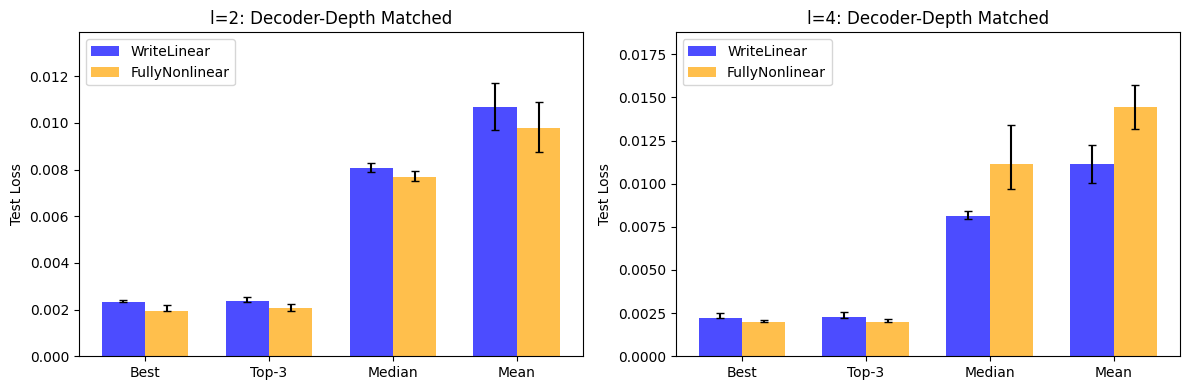

In [6]:
def bootstrap_quantile(data, quantile_func, n_bootstrap=1000):
    """Bootstrap CI for a quantile statistic."""
    boot_stats = []
    for _ in range(n_bootstrap):
        sample = np.random.choice(data, size=len(data), replace=True)
        boot_stats.append(quantile_func(sample))
    return np.percentile(boot_stats, [2.5, 97.5])


def quantile_analysis(losses_a, losses_b, label_a, label_b):
    """Compare two sets of losses at multiple quantiles.
    
    Diff % = (losses_a - losses_b) / losses_b * 100
    Positive = losses_a is worse (higher loss)
    Negative = losses_a is better (lower loss)
    """
    losses_a = np.array(sorted(losses_a))
    losses_b = np.array(sorted(losses_b))
    
    quantiles = {
        'best': lambda x: x[0],
        'top_3': lambda x: np.mean(x[:3]) if len(x) >= 3 else x[0],
        'median': np.median,
        'mean': np.mean
    }
    
    print(f"{'Quantile':<10} | {label_a:<18} | {label_b:<18} | Diff %")
    print("-" * 70)
    
    for name, func in quantiles.items():
        val_a = func(losses_a)
        val_b = func(losses_b)
        # Diff % relative to second argument (typically FullyNonlinear as baseline)
        diff_pct = (val_a - val_b) / val_b * 100 if val_b != 0 else 0
        
        ci_a = bootstrap_quantile(losses_a, func)
        ci_b = bootstrap_quantile(losses_b, func)
        
        print(f"{name:<10} | {val_a:.6f} [{ci_a[0]:.4f}, {ci_a[1]:.4f}] | {val_b:.6f} [{ci_b[0]:.4f}, {ci_b[1]:.4f}] | {diff_pct:+.1f}%")


print("ANALYSIS A: Decoder-Depth Matched Comparison")
print("=" * 70)
print("Comparing WriteLinear vs FullyNonlinear at the same decoder depth.")
print("WriteLinear has fewer params (linear encoder).")
print()
print("Note: Diff % = (WriteLinear - FullyNonlinear) / FullyNonlinear × 100")
print("      Positive = WriteLinear is worse (higher loss)")
print("      Negative = WriteLinear is better (lower loss)")
print()

for l in l_values:
    wl_params = count_parameters(WriteLinearAutoencoder(n=n, m=m, decoder_layers=l))
    fn_params = count_parameters(Autoencoder(n=n, m=m, l=l, tied_weights=False))
    
    print(f"\nl={l} (WriteLinear: {wl_params} params, FullyNonlinear: {fn_params} params)")
    print("-" * 70)
    
    wl_losses = [r['test_loss'] for r in results['WriteLinear'][l]]
    fn_losses = [r['test_loss'] for r in results['FullyNonlinear'][l]]
    
    quantile_analysis(wl_losses, fn_losses, 'WriteLinear', 'FullyNonlinear')
    
    # Statistical test
    stat, p_value = stats.mannwhitneyu(wl_losses, fn_losses, alternative='two-sided')
    print(f"\nMann-Whitney U test: p = {p_value:.4f}")
    if p_value > 0.05:
        print("  → Not statistically significant (cannot distinguish architectures)")
    else:
        better = 'WriteLinear' if np.mean(wl_losses) < np.mean(fn_losses) else 'FullyNonlinear'
        print(f"  → Statistically significant: {better} is better")

# Bar graph visualization with confidence intervals
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

stat_funcs = [
    lambda x: np.min(x),
    lambda x: np.mean(sorted(x)[:3]) if len(x) >= 3 else x[0],
    np.median,
    np.mean
]

for ax, l in zip(axes, l_values):
    wl_losses = np.array([r['test_loss'] for r in results['WriteLinear'][l]])
    fn_losses = np.array([r['test_loss'] for r in results['FullyNonlinear'][l]])
    
    x = np.arange(4)
    width = 0.35
    
    # Compute stats and CIs
    wl_stats = [f(wl_losses) for f in stat_funcs]
    fn_stats = [f(fn_losses) for f in stat_funcs]
    
    wl_cis = [bootstrap_quantile(wl_losses, f) for f in stat_funcs]
    fn_cis = [bootstrap_quantile(fn_losses, f) for f in stat_funcs]
    
    # Error bars: [lower_err, upper_err] for each stat
    wl_errs = np.array([[wl_stats[i] - wl_cis[i][0], wl_cis[i][1] - wl_stats[i]] for i in range(4)]).T
    fn_errs = np.array([[fn_stats[i] - fn_cis[i][0], fn_cis[i][1] - fn_stats[i]] for i in range(4)]).T
    
    bars1 = ax.bar(x - width/2, wl_stats, width, yerr=wl_errs, capsize=3,
                   label='WriteLinear', color='blue', alpha=0.7)
    bars2 = ax.bar(x + width/2, fn_stats, width, yerr=fn_errs, capsize=3,
                   label='FullyNonlinear', color='orange', alpha=0.7)
    
    ax.set_ylabel('Test Loss')
    ax.set_title(f'l={l}: Decoder-Depth Matched')
    ax.set_xticks(x)
    ax.set_xticklabels(['Best', 'Top-3', 'Median', 'Mean'])
    ax.legend()
    ax.set_ylim(0, max(max(wl_stats), max(fn_stats)) * 1.3)

plt.tight_layout()
plt.show()

/var/folders/y4/js36xx5s243220sv2my43_pm0000gn/T/ipykernel_15122/2989894688.py:24: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([wl_losses, fn_losses], labels=['WriteLinear', 'FullyNonlinear'],
/var/folders/y4/js36xx5s243220sv2my43_pm0000gn/T/ipykernel_15122/2989894688.py:24: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([wl_losses, fn_losses], labels=['WriteLinear', 'FullyNonlinear'],


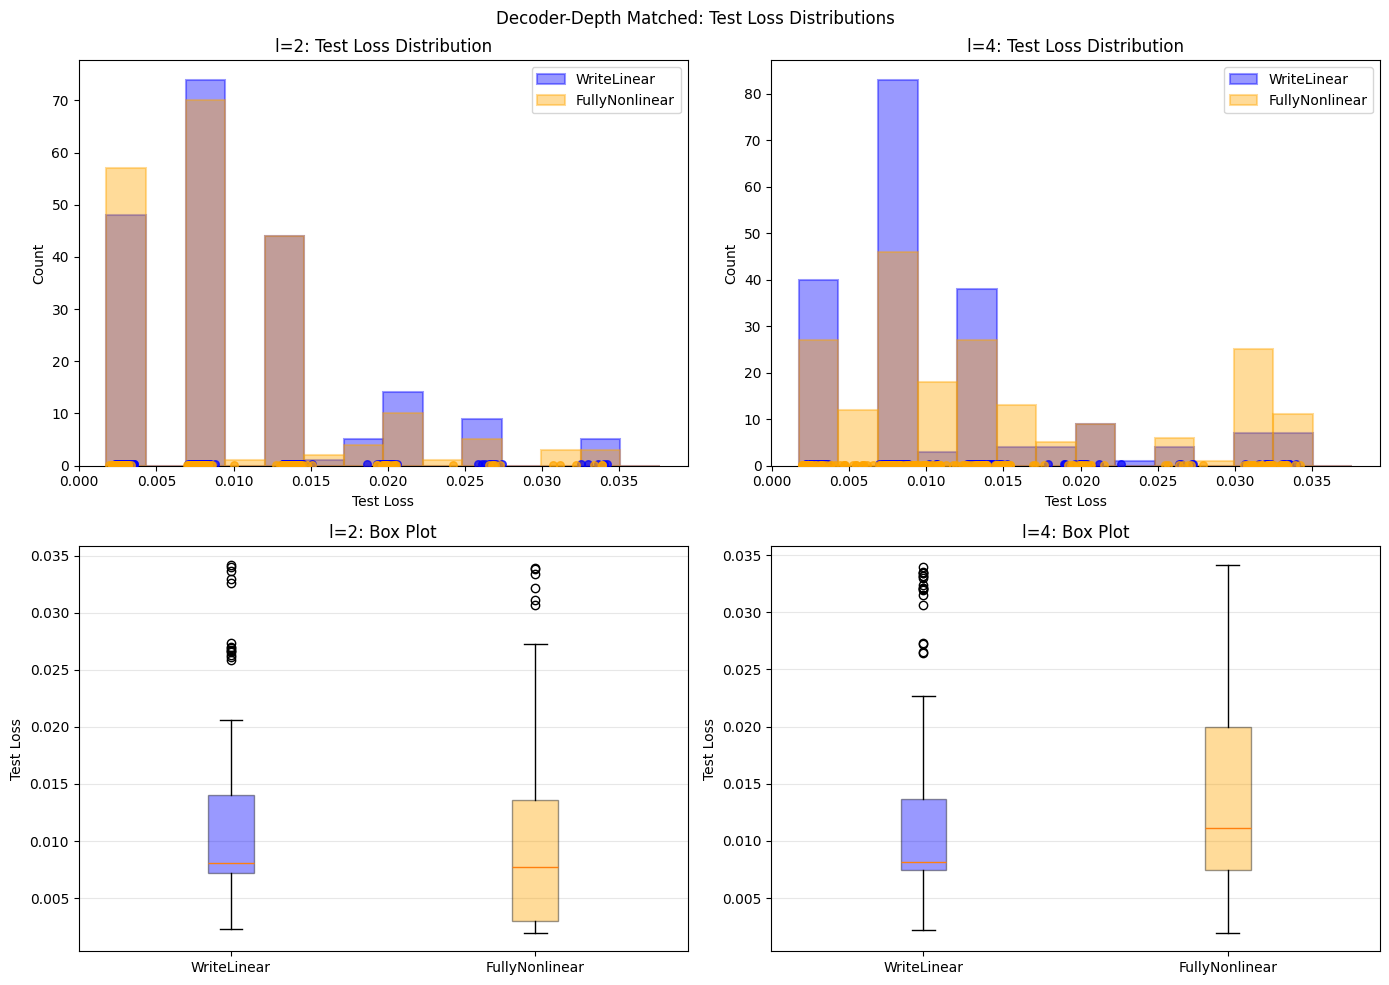

In [7]:
# Decoder-Depth Matched: Histograms + Box Plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for col, l in enumerate(l_values):
    wl_losses = [r['test_loss'] for r in results['WriteLinear'][l]]
    fn_losses = [r['test_loss'] for r in results['FullyNonlinear'][l]]
    
    # Top row: Histograms with seed points
    ax = axes[0, col]
    bins = np.linspace(min(wl_losses + fn_losses) * 0.9, max(wl_losses + fn_losses) * 1.1, 15)
    ax.hist(wl_losses, bins=bins, alpha=0.4, label='WriteLinear', color='blue', 
            edgecolor='blue', linewidth=1.5)
    ax.hist(fn_losses, bins=bins, alpha=0.4, label='FullyNonlinear', color='orange',
            edgecolor='orange', linewidth=1.5)
    ax.scatter(wl_losses, [0.3] * len(wl_losses), color='blue', s=30, alpha=0.7, zorder=5)
    ax.scatter(fn_losses, [0.1] * len(fn_losses), color='orange', s=30, alpha=0.7, zorder=5)
    ax.set_xlabel('Test Loss')
    ax.set_ylabel('Count')
    ax.set_title(f'l={l}: Test Loss Distribution')
    ax.legend()
    
    # Bottom row: Box plots
    ax = axes[1, col]
    bp = ax.boxplot([wl_losses, fn_losses], labels=['WriteLinear', 'FullyNonlinear'],
                    patch_artist=True)
    bp['boxes'][0].set_facecolor('blue')
    bp['boxes'][0].set_alpha(0.4)
    bp['boxes'][1].set_facecolor('orange')
    bp['boxes'][1].set_alpha(0.4)
    ax.set_ylabel('Test Loss')
    ax.set_title(f'l={l}: Box Plot')
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Decoder-Depth Matched: Test Loss Distributions', fontsize=12)
plt.tight_layout()
plt.show()

### 1.2 Parameter-Matched Comparison

Compare WriteLinear(l=3) [85 params] vs FullyNonlinear(l=2) [87 params].
Similar parameter budgets, different architectural choices.

In [8]:
# We need to run WriteLinear with l=3 to match FullyNonlinear l=2 params
print("Running additional WriteLinear(l=3) for parameter-matched comparison...")
print()

l_match = 3
results['WriteLinear'][l_match] = []
best_models['WriteLinear'][l_match] = None
best_losses['WriteLinear'][l_match] = float('inf')

l3_start = time.time()

for seed in tqdm(range(n_seeds), desc=f"WriteLinear l={l_match}"):
    torch.manual_seed(seed)
    np.random.seed(seed)
    
    model_wl = WriteLinearAutoencoder(n=n, m=m, decoder_layers=l_match).to(device)
    losses_wl = train_model(model_wl, n_steps=n_steps, S=S, verbose=False)
    
    test_loss_wl = evaluate_model(model_wl, S=S)
    train_loss_wl = np.mean(losses_wl[-100:])
    arc_chord_wl, traj_wl = compute_arc_chord_ratio(model_wl)
    nonlin_metrics_wl = compute_all_nonlinearity_metrics(model_wl, S=S, mse_linear_ae=mse_linear_ae)
    
    result_wl = {
        'seed': seed,
        'test_loss': test_loss_wl,
        'train_loss': train_loss_wl,
        'losses': losses_wl,
        **nonlin_metrics_wl
    }
    results['WriteLinear'][l_match].append(result_wl)
    
    if test_loss_wl < best_losses['WriteLinear'][l_match]:
        best_losses['WriteLinear'][l_match] = test_loss_wl
        best_models['WriteLinear'][l_match] = model_wl.state_dict().copy()
        result_wl['model'] = model_wl

l3_elapsed = time.time() - l3_start
print(f"\nCompleted WriteLinear l={l_match} in {l3_elapsed/60:.1f} minutes")

# Save updated results
final_results['results'] = results
final_results['best_models'] = best_models
final_results['best_losses'] = best_losses
with open(results_dir / 'final_results.pkl', 'wb') as f:
    pickle.dump(final_results, f)
print(f"Updated final_results.pkl")

Running additional WriteLinear(l=3) for parameter-matched comparison...



WriteLinear l=3:   0%|          | 0/200 [00:00<?, ?it/s]

WriteLinear l=3:   0%|          | 1/200 [00:07<23:32,  7.10s/it]

WriteLinear l=3:   1%|          | 2/200 [00:14<23:13,  7.04s/it]

WriteLinear l=3:   2%|▏         | 3/200 [00:21<23:22,  7.12s/it]

...

WriteLinear l=3: 100%|█████████▉| 199/200 [22:17<00:06,  6.34s/it]

WriteLinear l=3: 100%|██████████| 200/200 [22:23<00:00,  6.33s/it]

WriteLinear l=3: 100%|██████████| 200/200 [22:23<00:00,  6.72s/it]


Completed WriteLinear l=3 in 22.4 minutes


Updated final_results.pkl


ANALYSIS B: Parameter-Matched Comparison

Parameter counts:
----------------------------------------
WriteLinear(l=2):     55 params
WriteLinear(l=3):     85 params
WriteLinear(l=4):     115 params
FullyNonlinear(l=2):  87 params
FullyNonlinear(l=4):  207 params

Matched comparison: WriteLinear(l=3) [85 params] vs FullyNonlinear(l=2) [87 params]
----------------------------------------------------------------------

Note: Diff % = (WriteLinear - FullyNonlinear) / FullyNonlinear × 100
      Positive = WriteLinear is worse (higher loss)
      Negative = WriteLinear is better (lower loss)

Quantile   | WriteLinear(l=3)   | FullyNonlin(l=2)   | Diff %
----------------------------------------------------------------------
best       | 0.002119 [0.0025, 0.0315] | 0.001958 [0.0023, 0.0311] | +8.2%
top_3      | 0.002251 [0.0043, 0.0201] | 0.002072 [0.0040, 0.0187] | +8.7%
median     | 0.007937 [0.0078, 0.0081] | 0.007691 [0.0075, 0.0079] | +3.2%
mean       | 0.010480 [0.0094, 0.0116] | 0.00978

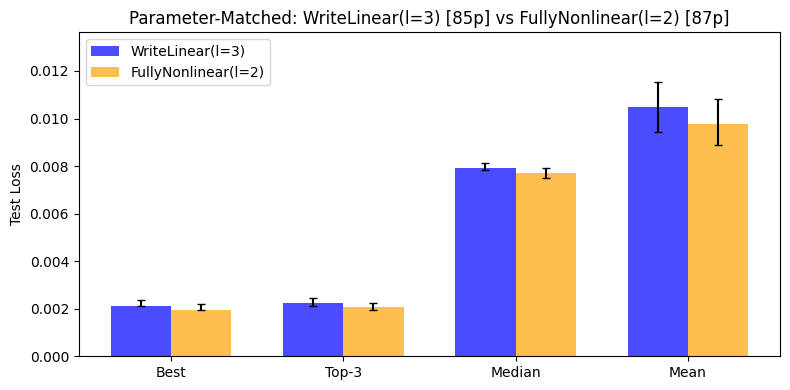

In [9]:
print("ANALYSIS B: Parameter-Matched Comparison")
print("=" * 70)
print()

# Parameter count table
print("Parameter counts:")
print("-" * 40)
for l_test in [2, 3, 4]:
    wl_params = count_parameters(WriteLinearAutoencoder(n=n, m=m, decoder_layers=l_test))
    print(f"WriteLinear(l={l_test}):     {wl_params} params")
for l_test in [2, 4]:
    fn_params = count_parameters(Autoencoder(n=n, m=m, l=l_test, tied_weights=False))
    print(f"FullyNonlinear(l={l_test}):  {fn_params} params")

print()
print("Matched comparison: WriteLinear(l=3) [85 params] vs FullyNonlinear(l=2) [87 params]")
print("-" * 70)
print()
print("Note: Diff % = (WriteLinear - FullyNonlinear) / FullyNonlinear × 100")
print("      Positive = WriteLinear is worse (higher loss)")
print("      Negative = WriteLinear is better (lower loss)")
print()

wl_losses = np.array([r['test_loss'] for r in results['WriteLinear'][3]])
fn_losses = np.array([r['test_loss'] for r in results['FullyNonlinear'][2]])

quantile_analysis(wl_losses, fn_losses, 'WriteLinear(l=3)', 'FullyNonlin(l=2)')

stat, p_value = stats.mannwhitneyu(wl_losses, fn_losses, alternative='two-sided')
print(f"\nMann-Whitney U test: p = {p_value:.4f}")
if p_value > 0.05:
    print("  → Not statistically significant")
else:
    better = 'WriteLinear(l=3)' if np.mean(wl_losses) < np.mean(fn_losses) else 'FullyNonlinear(l=2)'
    print(f"  → Statistically significant: {better} is better")

# Bar graph visualization with confidence intervals
fig, ax = plt.subplots(figsize=(8, 4))

x = np.arange(4)
width = 0.35

stat_funcs = [
    lambda x: np.min(x),
    lambda x: np.mean(sorted(x)[:3]) if len(x) >= 3 else x[0],
    np.median,
    np.mean
]

wl_stats = [f(wl_losses) for f in stat_funcs]
fn_stats = [f(fn_losses) for f in stat_funcs]

wl_cis = [bootstrap_quantile(wl_losses, f) for f in stat_funcs]
fn_cis = [bootstrap_quantile(fn_losses, f) for f in stat_funcs]

wl_errs = np.array([[wl_stats[i] - wl_cis[i][0], wl_cis[i][1] - wl_stats[i]] for i in range(4)]).T
fn_errs = np.array([[fn_stats[i] - fn_cis[i][0], fn_cis[i][1] - fn_stats[i]] for i in range(4)]).T

bars1 = ax.bar(x - width/2, wl_stats, width, yerr=wl_errs, capsize=3,
               label='WriteLinear(l=3)', color='blue', alpha=0.7)
bars2 = ax.bar(x + width/2, fn_stats, width, yerr=fn_errs, capsize=3,
               label='FullyNonlinear(l=2)', color='orange', alpha=0.7)

ax.set_ylabel('Test Loss')
ax.set_title('Parameter-Matched: WriteLinear(l=3) [85p] vs FullyNonlinear(l=2) [87p]')
ax.set_xticks(x)
ax.set_xticklabels(['Best', 'Top-3', 'Median', 'Mean'])
ax.legend()
ax.set_ylim(0, max(max(wl_stats), max(fn_stats)) * 1.3)

plt.tight_layout()
plt.show()

/var/folders/y4/js36xx5s243220sv2my43_pm0000gn/T/ipykernel_15122/3477737891.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([wl_losses, fn_losses], labels=['WriteLinear(l=3)', 'FullyNonlin(l=2)'],


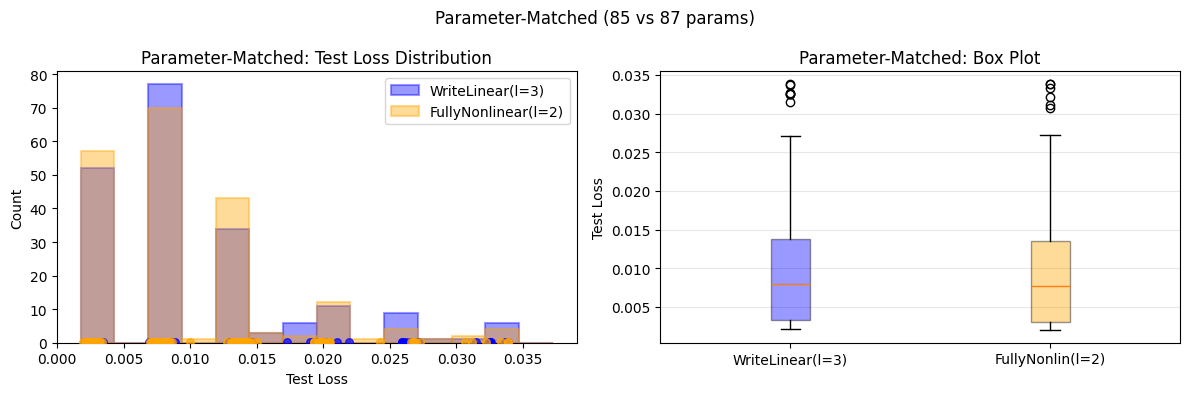

In [10]:
# Parameter-Matched: Histogram + Box Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

wl_losses = [r['test_loss'] for r in results['WriteLinear'][3]]
fn_losses = [r['test_loss'] for r in results['FullyNonlinear'][2]]

# Histogram with seed points
ax = axes[0]
bins = np.linspace(min(wl_losses + fn_losses) * 0.9, max(wl_losses + fn_losses) * 1.1, 15)
ax.hist(wl_losses, bins=bins, alpha=0.4, label='WriteLinear(l=3)', color='blue', 
        edgecolor='blue', linewidth=1.5)
ax.hist(fn_losses, bins=bins, alpha=0.4, label='FullyNonlinear(l=2)', color='orange',
        edgecolor='orange', linewidth=1.5)
ax.scatter(wl_losses, [0.3] * len(wl_losses), color='blue', s=30, alpha=0.7, zorder=5)
ax.scatter(fn_losses, [0.1] * len(fn_losses), color='orange', s=30, alpha=0.7, zorder=5)
ax.set_xlabel('Test Loss')
ax.set_ylabel('Count')
ax.set_title('Parameter-Matched: Test Loss Distribution')
ax.legend()

# Box plot
ax = axes[1]
bp = ax.boxplot([wl_losses, fn_losses], labels=['WriteLinear(l=3)', 'FullyNonlin(l=2)'],
                patch_artist=True)
bp['boxes'][0].set_facecolor('blue')
bp['boxes'][0].set_alpha(0.4)
bp['boxes'][1].set_facecolor('orange')
bp['boxes'][1].set_alpha(0.4)
ax.set_ylabel('Test Loss')
ax.set_title('Parameter-Matched: Box Plot')
ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Parameter-Matched (85 vs 87 params)', fontsize=12)
plt.tight_layout()
plt.show()

## 2. Secondary Metrics: Loss-Related

Metrics that provide more detail about the loss landscape and training dynamics.

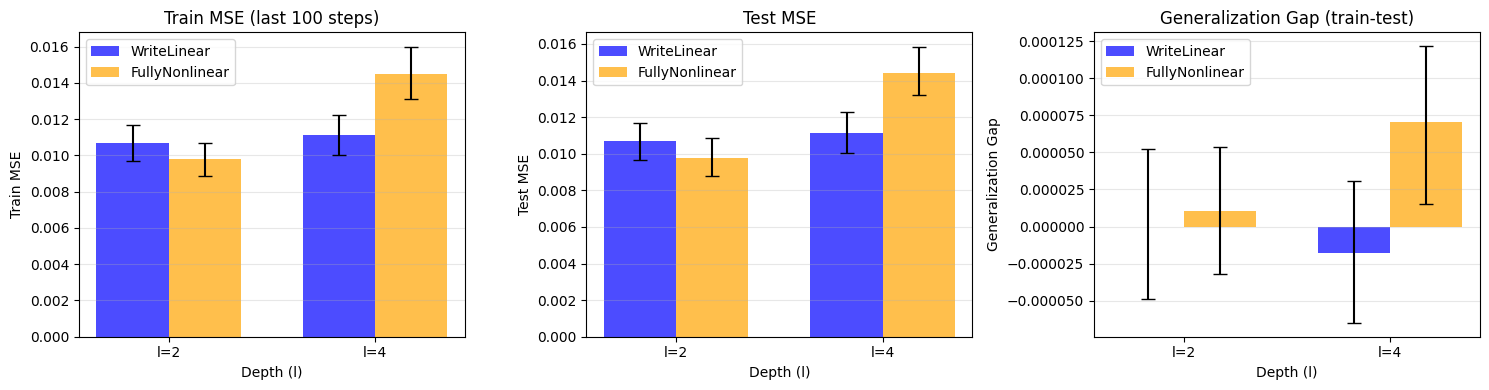


Numeric Summary:

l=2:
  WriteLinear:
    Train: 0.010678 ± 0.007189
    Test:  0.010678 ± 0.007205
    Gap:   -0.000000 ± 0.000363
  FullyNonlinear:
    Train: 0.009793 ± 0.007096
    Test:  0.009783 ± 0.007143
    Gap:   0.000010 ± 0.000303

l=4:
  WriteLinear:
    Train: 0.011110 ± 0.007875
    Test:  0.011127 ± 0.007882
    Gap:   -0.000018 ± 0.000356
  FullyNonlinear:
    Train: 0.014509 ± 0.009922
    Test:  0.014438 ± 0.009935
    Gap:   0.000071 ± 0.000395


In [11]:
# Train MSE & Generalization Gap with Bar Graphs + CIs
def bootstrap_ci(data, n_bootstrap=1000, ci=95):
    """Compute bootstrap confidence interval for the mean."""
    means = []
    for _ in range(n_bootstrap):
        sample = np.random.choice(data, size=len(data), replace=True)
        means.append(np.mean(sample))
    lower = np.percentile(means, (100-ci)/2)
    upper = np.percentile(means, 100-(100-ci)/2)
    return lower, upper

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
metrics = [('train_loss', 'Train MSE (last 100 steps)'), 
           ('test_loss', 'Test MSE'),
           ('gen_gap', 'Generalization Gap (train-test)')]

for ax, (metric, title) in zip(axes, metrics):
    x = np.arange(len(l_values))
    width = 0.35
    
    wl_means, wl_errs = [], []
    fn_means, fn_errs = [], []
    
    for l in l_values:
        wl_vals = [r[metric] for r in results['WriteLinear'][l]]
        fn_vals = [r[metric] for r in results['FullyNonlinear'][l]]
        
        wl_means.append(np.mean(wl_vals))
        fn_means.append(np.mean(fn_vals))
        
        wl_ci = bootstrap_ci(wl_vals)
        fn_ci = bootstrap_ci(fn_vals)
        wl_errs.append([wl_means[-1] - wl_ci[0], wl_ci[1] - wl_means[-1]])
        fn_errs.append([fn_means[-1] - fn_ci[0], fn_ci[1] - fn_means[-1]])
    
    wl_errs = np.array(wl_errs).T
    fn_errs = np.array(fn_errs).T
    
    ax.bar(x - width/2, wl_means, width, yerr=wl_errs, label='WriteLinear', 
           color='blue', alpha=0.7, capsize=5)
    ax.bar(x + width/2, fn_means, width, yerr=fn_errs, label='FullyNonlinear', 
           color='orange', alpha=0.7, capsize=5)
    
    ax.set_xlabel('Depth (l)')
    ax.set_ylabel(title.split('(')[0].strip())
    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels([f'l={l}' for l in l_values])
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Print numeric values
print("\nNumeric Summary:")
print("=" * 70)
for l in l_values:
    print(f"\nl={l}:")
    for arch in ['WriteLinear', 'FullyNonlinear']:
        train = [r['train_loss'] for r in results[arch][l]]
        test = [r['test_loss'] for r in results[arch][l]]
        gap = [r['gen_gap'] for r in results[arch][l]]
        print(f"  {arch}:")
        print(f"    Train: {np.mean(train):.6f} ± {np.std(train):.6f}")
        print(f"    Test:  {np.mean(test):.6f} ± {np.std(test):.6f}")
        print(f"    Gap:   {np.mean(gap):.6f} ± {np.std(gap):.6f}")

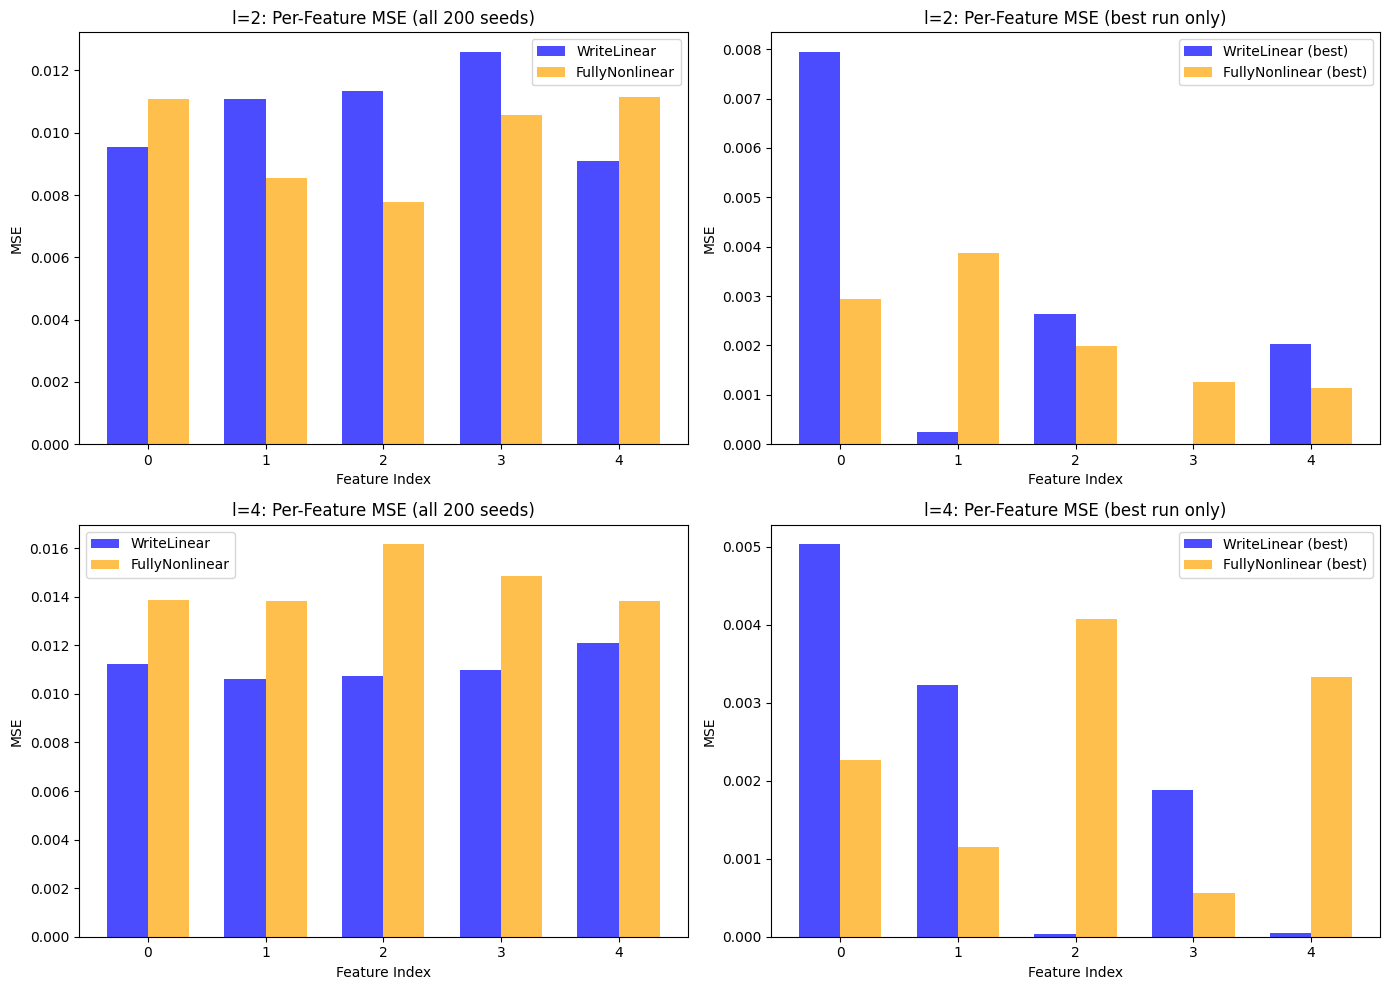


Per-Feature MSE Significance Analysis

Note: With only 10 seeds, statistical power is limited.
These patterns should be verified with more runs before drawing conclusions.

l=2:
  Feature 0: WL-FN = -0.001520 (-13.7%) CI=[-0.004118, 0.001115] 
  Feature 1: WL-FN = +0.002548 (+29.9%) CI=[-0.000010, 0.005103] 
  Feature 2: WL-FN = +0.003557 (+45.7%) CI=[0.000705, 0.006144] **
  Feature 3: WL-FN = +0.002037 (+19.3%) CI=[-0.000795, 0.004741] 
  Feature 4: WL-FN = -0.002074 (-18.6%) CI=[-0.004845, 0.000764] 

l=4:
  Feature 0: WL-FN = -0.002651 (-19.1%) CI=[-0.005384, 0.000048] 
  Feature 1: WL-FN = -0.003226 (-23.3%) CI=[-0.006103, -0.000553] **
  Feature 2: WL-FN = -0.005397 (-33.4%) CI=[-0.008353, -0.002599] **
  Feature 3: WL-FN = -0.003876 (-26.1%) CI=[-0.006614, -0.000962] **
  Feature 4: WL-FN = -0.001749 (-12.6%) CI=[-0.004506, 0.000952] 


** = 95% CI excludes zero (potentially significant, but verify with more data)

Theoretical consideration:
If features have equal importance in

In [12]:
# Per-Feature MSE Analysis
# Compare: all-seeds average, top-3 average, best run

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for row, l in enumerate(l_values):
    # Left: All seeds average
    ax = axes[row, 0]
    wl_per_feat_all = np.mean([r['per_feature_mse'] for r in results['WriteLinear'][l]], axis=0)
    fn_per_feat_all = np.mean([r['per_feature_mse'] for r in results['FullyNonlinear'][l]], axis=0)
    
    x = np.arange(n)
    width = 0.35
    ax.bar(x - width/2, wl_per_feat_all, width, label='WriteLinear', color='blue', alpha=0.7)
    ax.bar(x + width/2, fn_per_feat_all, width, label='FullyNonlinear', color='orange', alpha=0.7)
    ax.set_xlabel('Feature Index')
    ax.set_ylabel('MSE')
    ax.set_title(f'l={l}: Per-Feature MSE (all {n_seeds} seeds)')
    ax.set_xticks(x)
    ax.legend()
    
    # Right: Best run only
    ax = axes[row, 1]
    best_wl = min(results['WriteLinear'][l], key=lambda r: r['test_loss'])
    best_fn = min(results['FullyNonlinear'][l], key=lambda r: r['test_loss'])
    
    ax.bar(x - width/2, best_wl['per_feature_mse'], width, label='WriteLinear (best)', color='blue', alpha=0.7)
    ax.bar(x + width/2, best_fn['per_feature_mse'], width, label='FullyNonlinear (best)', color='orange', alpha=0.7)
    ax.set_xlabel('Feature Index')
    ax.set_ylabel('MSE')
    ax.set_title(f'l={l}: Per-Feature MSE (best run only)')
    ax.set_xticks(x)
    ax.legend()

plt.tight_layout()
plt.show()

# Statistical analysis: which features differ significantly?
print("\nPer-Feature MSE Significance Analysis")
print("=" * 70)
print("\nNote: With only 10 seeds, statistical power is limited.")
print("These patterns should be verified with more runs before drawing conclusions.")
print()

for l in l_values:
    print(f"l={l}:")
    wl_feats = np.array([r['per_feature_mse'] for r in results['WriteLinear'][l]])
    fn_feats = np.array([r['per_feature_mse'] for r in results['FullyNonlinear'][l]])
    
    for i in range(n):
        wl_i = wl_feats[:, i]
        fn_i = fn_feats[:, i]
        diff = np.mean(wl_i) - np.mean(fn_i)
        diff_pct = diff / np.mean(fn_i) * 100 if np.mean(fn_i) > 0 else 0
        
        # Bootstrap CI for difference
        diffs = []
        for _ in range(1000):
            wl_s = np.random.choice(wl_i, size=len(wl_i), replace=True)
            fn_s = np.random.choice(fn_i, size=len(fn_i), replace=True)
            diffs.append(np.mean(wl_s) - np.mean(fn_s))
        ci_low, ci_high = np.percentile(diffs, [2.5, 97.5])
        
        sig = "**" if ci_low > 0 or ci_high < 0 else ""
        print(f"  Feature {i}: WL-FN = {diff:+.6f} ({diff_pct:+.1f}%) CI=[{ci_low:.6f}, {ci_high:.6f}] {sig}")
    print()

print("\n** = 95% CI excludes zero (potentially significant, but verify with more data)")
print("\nTheoretical consideration:")
print("If features have equal importance in the data distribution, differences may arise from:")
print("- Encoder geometry: which features get projected to similar/different directions")
print("- Decoder capacity: nonlinear decoder may better separate overlapping projections")

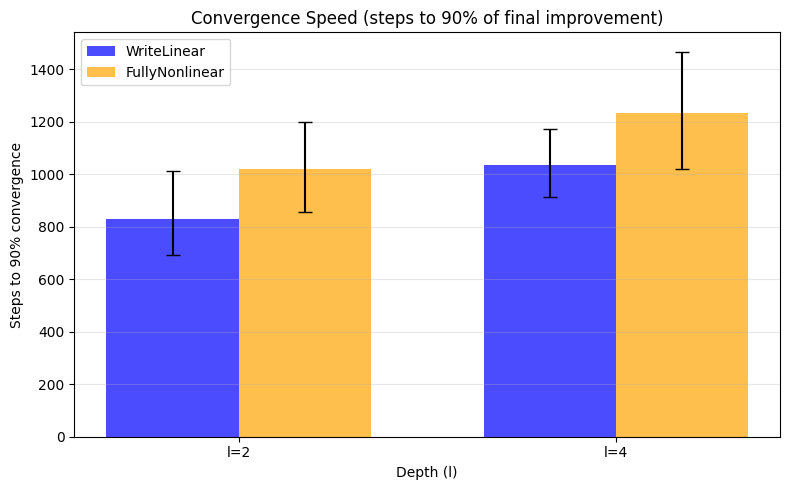


Numeric Summary:
l=2: WriteLinear=830±1164, FullyNonlinear=1019±1294, Ratio=0.81x
l=4: WriteLinear=1036±950, FullyNonlinear=1232±1696, Ratio=0.84x


In [13]:
# Convergence Speed with Bar Graph + CIs
fig, ax = plt.subplots(figsize=(8, 5))

x = np.arange(len(l_values))
width = 0.35

wl_means, wl_errs = [], []
fn_means, fn_errs = [], []

for l in l_values:
    wl_speeds = [r['convergence_speed'] for r in results['WriteLinear'][l]]
    fn_speeds = [r['convergence_speed'] for r in results['FullyNonlinear'][l]]
    
    wl_means.append(np.mean(wl_speeds))
    fn_means.append(np.mean(fn_speeds))
    
    wl_ci = bootstrap_ci(wl_speeds)
    fn_ci = bootstrap_ci(fn_speeds)
    wl_errs.append([wl_means[-1] - wl_ci[0], wl_ci[1] - wl_means[-1]])
    fn_errs.append([fn_means[-1] - fn_ci[0], fn_ci[1] - fn_means[-1]])

wl_errs = np.array(wl_errs).T
fn_errs = np.array(fn_errs).T

ax.bar(x - width/2, wl_means, width, yerr=wl_errs, label='WriteLinear', 
       color='blue', alpha=0.7, capsize=5)
ax.bar(x + width/2, fn_means, width, yerr=fn_errs, label='FullyNonlinear', 
       color='orange', alpha=0.7, capsize=5)

ax.set_xlabel('Depth (l)')
ax.set_ylabel('Steps to 90% convergence')
ax.set_title('Convergence Speed (steps to 90% of final improvement)')
ax.set_xticks(x)
ax.set_xticklabels([f'l={l}' for l in l_values])
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Print numeric values
print("\nNumeric Summary:")
for l in l_values:
    wl_speeds = [r['convergence_speed'] for r in results['WriteLinear'][l]]
    fn_speeds = [r['convergence_speed'] for r in results['FullyNonlinear'][l]]
    print(f"l={l}: WriteLinear={np.mean(wl_speeds):.0f}±{np.std(wl_speeds):.0f}, " +
          f"FullyNonlinear={np.mean(fn_speeds):.0f}±{np.std(fn_speeds):.0f}, " +
          f"Ratio={np.mean(wl_speeds)/np.mean(fn_speeds):.2f}x")

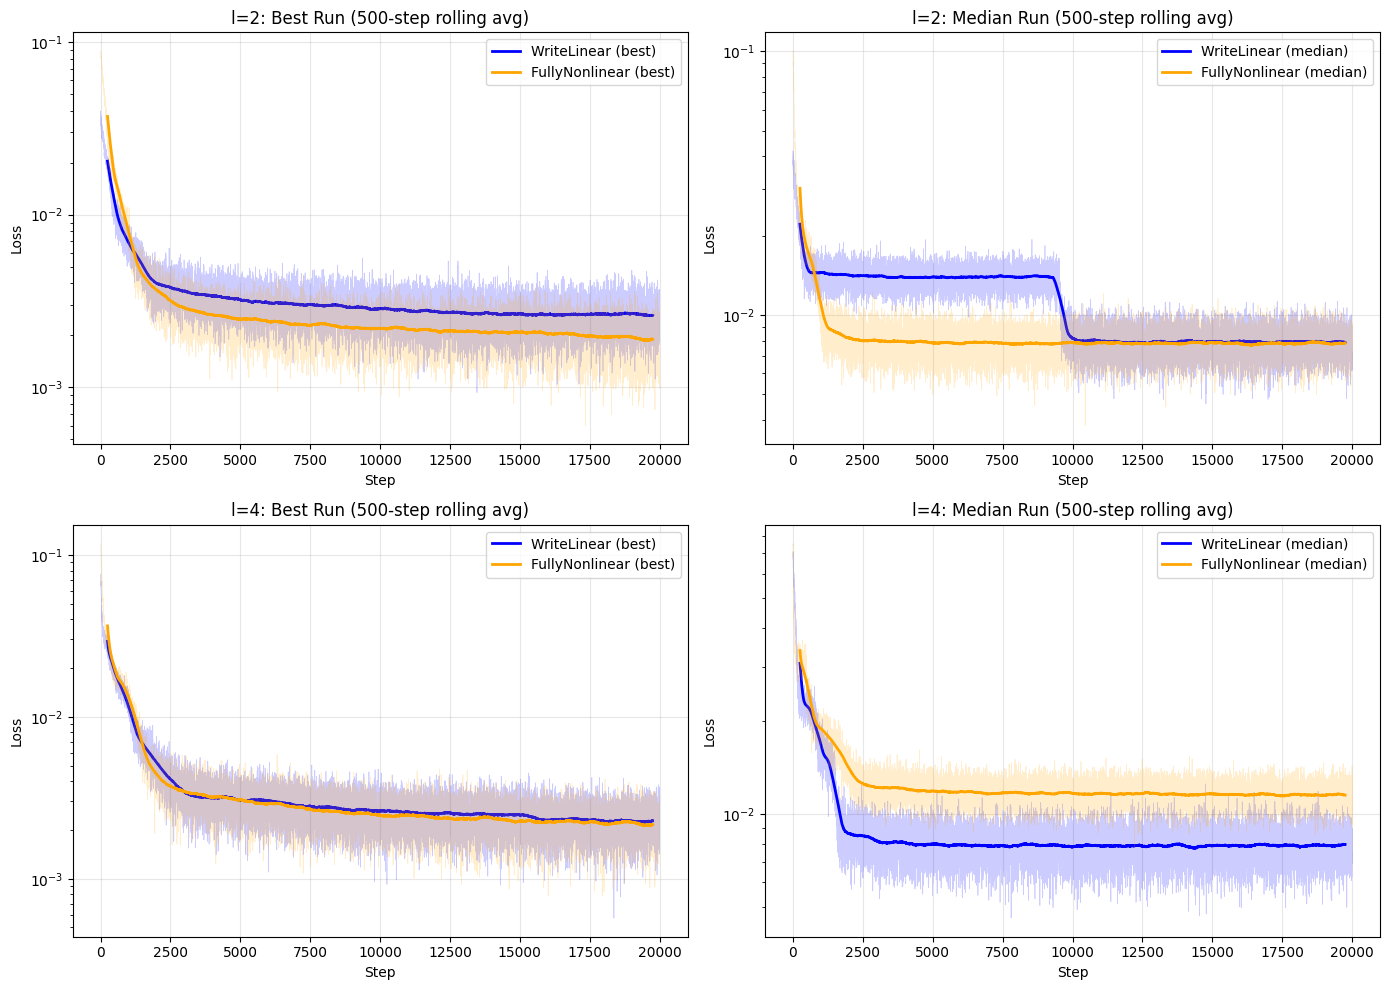

In [14]:
def rolling_average(data, window=500):
    """Compute rolling average with given window size."""
    kernel = np.ones(window) / window
    return np.convolve(data, kernel, mode='valid')

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for row, l in enumerate(l_values):
    for col, run_type in enumerate(['best', 'median']):
        ax = axes[row, col]
        
        for arch, color in [('WriteLinear', 'blue'), ('FullyNonlinear', 'orange')]:
            runs = results[arch][l]
            sorted_runs = sorted(runs, key=lambda r: r['test_loss'])
            
            if run_type == 'best':
                selected_run = sorted_runs[0]
            else:  # median
                selected_run = sorted_runs[len(sorted_runs) // 2]
            
            # Raw data (translucent)
            ax.plot(selected_run['losses'], color=color, linewidth=0.5, alpha=0.2)
            
            # Rolling average (opaque)
            smoothed = rolling_average(selected_run['losses'], window=500)
            ax.plot(np.arange(len(smoothed)) + 250, smoothed, color=color, 
                    linewidth=2, label=f'{arch} ({run_type})')
        
        ax.set_xlabel('Step')
        ax.set_ylabel('Loss')
        ax.set_yscale('log')
        ax.set_title(f'l={l}: {run_type.capitalize()} Run (500-step rolling avg)')
        ax.legend(loc='upper right')
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Nonlinearity Metrics

Measuring how nonlinear the encoder and decoder are, and where that nonlinearity helps.

### 3.1 Feature Trajectory Analysis

Examining encoder behavior along single-feature trajectories z(t·eᵢ) for t ∈ [0,1].

**Arc/chord ratio**: Linear encoder → straight line (ratio = 1.0). Nonlinear → curved (ratio > 1.0).

**Gradient/velocity**: How fast does ||z|| change as we increase input magnitude?

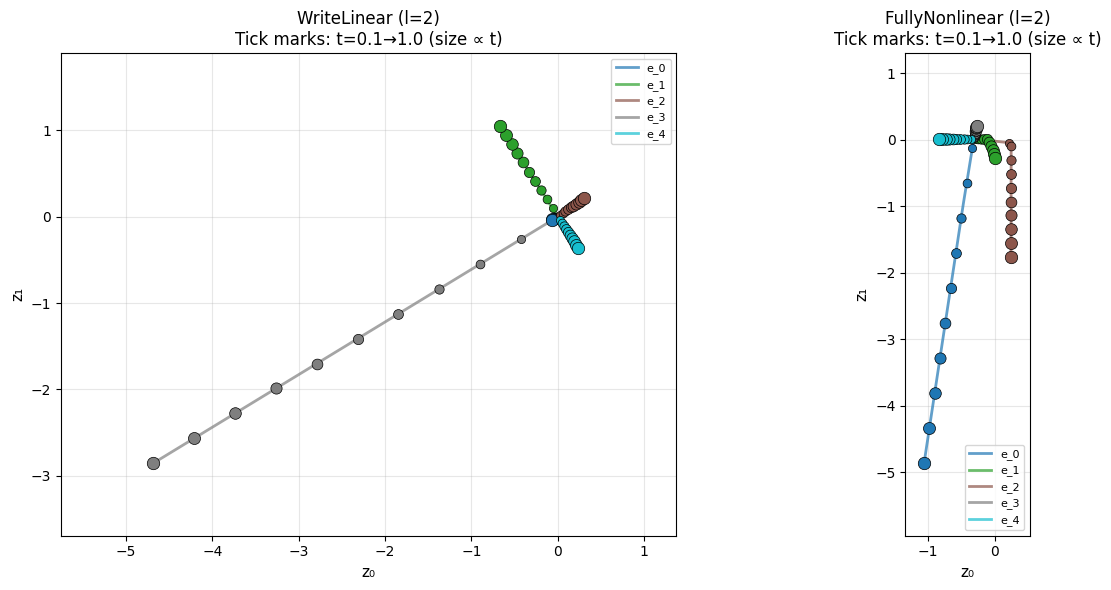

Even tick spacing = constant velocity (linear encoder)
Bunched/spread ticks = variable velocity (nonlinear encoder)


In [15]:
# Feature Trajectories with Tick Marks (t = 0.1, 0.2, ..., 1.0)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

l_viz = 2
tick_t = np.linspace(0.1, 1.0, 10)

for ax, arch in zip(axes, ['WriteLinear', 'FullyNonlinear']):
    best_run = min(results[arch][l_viz], key=lambda r: r['test_loss'])
    model = best_run['model']
    colors = plt.cm.tab10(np.linspace(0, 1, n))
    
    with torch.no_grad():
        for i in range(n):
            # Full trajectory
            t_full = torch.linspace(0, 1, 100)
            traj = torch.zeros(100, n, device=device)
            traj[:, i] = t_full.to(device)
            z_traj = model.encode(traj).cpu().numpy()
            
            ax.plot(z_traj[:, 0], z_traj[:, 1], color=colors[i], linewidth=2, 
                    label=f'e_{i}', alpha=0.7)
            
            # Tick marks at specific t values (size increases with t)
            for t in tick_t:
                idx = int(t * 99)
                ax.scatter(z_traj[idx, 0], z_traj[idx, 1], color=colors[i], 
                          s=30 + 50*t, zorder=5, edgecolor='black', linewidth=0.5)
    
    ax.set_xlabel('z₀', fontsize=11)
    ax.set_ylabel('z₁', fontsize=11)
    ax.set_title(f'{arch} (l={l_viz})\nTick marks: t=0.1→1.0 (size ∝ t)')
    ax.legend(loc='best', fontsize=8)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    
    # Whitespace padding
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    x_pad = (xlim[1] - xlim[0]) * 0.15
    y_pad = (ylim[1] - ylim[0]) * 0.15
    ax.set_xlim(xlim[0] - x_pad, xlim[1] + x_pad)
    ax.set_ylim(ylim[0] - y_pad, ylim[1] + y_pad)

plt.tight_layout()
plt.show()

print("Even tick spacing = constant velocity (linear encoder)")
print("Bunched/spread ticks = variable velocity (nonlinear encoder)")

Arc/Chord Ratio Verification

l=2:
  WriteLinear:     mean=1.00000000, max_dev_from_1=7.11e-08
  FullyNonlinear:  mean=1.0209, range=[1.0000, 2.2053]

l=4:
  WriteLinear:     mean=1.00000000, max_dev_from_1=7.43e-08
  FullyNonlinear:  mean=1.0777, range=[1.0000, 2.0360]

✓ Confirmed: WriteLinear has arc/chord = 1.0 exactly (linear encoder)


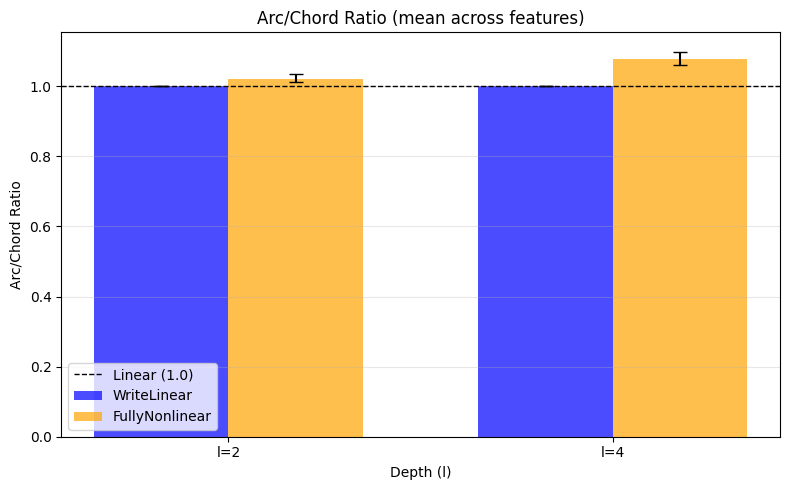

In [16]:
# Arc/Chord Ratio: Statistics + Bar Graph with CI

# Statistical verification
print("Arc/Chord Ratio Verification")
print("=" * 60)

for l in l_values:
    wl_ratios = [r['arc_chord_mean'] for r in results['WriteLinear'][l]]
    fn_ratios = [r['arc_chord_mean'] for r in results['FullyNonlinear'][l]]
    
    print(f"\nl={l}:")
    print(f"  WriteLinear:     mean={np.mean(wl_ratios):.8f}, max_dev_from_1={max(abs(r-1) for r in wl_ratios):.2e}")
    print(f"  FullyNonlinear:  mean={np.mean(fn_ratios):.4f}, range=[{np.min(fn_ratios):.4f}, {np.max(fn_ratios):.4f}]")

# Sanity check
all_wl_ratios = [r['arc_chord_mean'] for l in l_values for r in results['WriteLinear'][l]]
max_dev = max(abs(r - 1.0) for r in all_wl_ratios)
if max_dev < 1e-6:
    print(f"\n✓ Confirmed: WriteLinear has arc/chord = 1.0 exactly (linear encoder)")
else:
    print(f"\n⚠ Unexpected deviation: {max_dev:.2e}")

# Bar graph with CI
fig, ax = plt.subplots(figsize=(8, 5))

x = np.arange(len(l_values))
width = 0.35

wl_means, wl_errs = [], []
fn_means, fn_errs = [], []

for l in l_values:
    wl_ratios = [r['arc_chord_mean'] for r in results['WriteLinear'][l]]
    fn_ratios = [r['arc_chord_mean'] for r in results['FullyNonlinear'][l]]
    
    wl_means.append(np.mean(wl_ratios))
    fn_means.append(np.mean(fn_ratios))
    
    wl_ci = bootstrap_ci(wl_ratios)
    fn_ci = bootstrap_ci(fn_ratios)
    wl_errs.append([wl_means[-1] - wl_ci[0], wl_ci[1] - wl_means[-1]])
    fn_errs.append([fn_means[-1] - fn_ci[0], fn_ci[1] - fn_means[-1]])

wl_errs = np.array(wl_errs).T
fn_errs = np.array(fn_errs).T

ax.bar(x - width/2, wl_means, width, yerr=wl_errs, label='WriteLinear', 
       color='blue', alpha=0.7, capsize=5)
ax.bar(x + width/2, fn_means, width, yerr=fn_errs, label='FullyNonlinear', 
       color='orange', alpha=0.7, capsize=5)

ax.axhline(y=1.0, color='black', linestyle='--', linewidth=1, label='Linear (1.0)')
ax.set_xlabel('Depth (l)')
ax.set_ylabel('Arc/Chord Ratio')
ax.set_title('Arc/Chord Ratio (mean across features)')
ax.set_xticks(x)
ax.set_xticklabels([f'l={l}' for l in l_values])
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

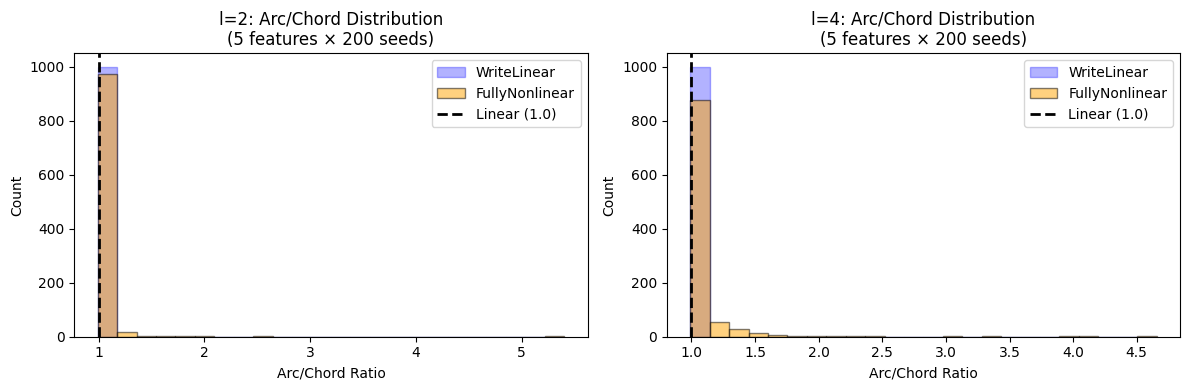

WriteLinear spike at 1.0 confirms linear encoder (sanity check)
FullyNonlinear spread > 1.0 indicates curved trajectories


In [17]:
# Arc/Chord Ratio Distribution (both architectures)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, l in zip(axes, l_values):
    # WriteLinear - show as translucent (sanity check that it's at 1.0)
    wl_ratios = []
    for r in results['WriteLinear'][l]:
        wl_ratios.extend(r['arc_chord_ratios'])
    
    # FullyNonlinear
    fn_ratios = []
    for r in results['FullyNonlinear'][l]:
        fn_ratios.extend(r['arc_chord_ratios'])
    
    # Use same bins for both
    all_ratios = wl_ratios + fn_ratios
    bins = np.linspace(min(all_ratios) - 0.01, max(all_ratios) + 0.1, 25)
    
    ax.hist(wl_ratios, bins=bins, alpha=0.3, color='blue', edgecolor='blue',
            linewidth=1, label='WriteLinear')
    ax.hist(fn_ratios, bins=bins, alpha=0.5, color='orange', edgecolor='black',
            label='FullyNonlinear')
    ax.axvline(x=1.0, color='black', linestyle='--', linewidth=2, label='Linear (1.0)')
    
    ax.set_xlabel('Arc/Chord Ratio')
    ax.set_ylabel('Count')
    ax.set_title(f'l={l}: Arc/Chord Distribution\n({n} features × {n_seeds} seeds)')
    ax.legend()

plt.tight_layout()
plt.show()

print("WriteLinear spike at 1.0 confirms linear encoder (sanity check)")
print("FullyNonlinear spread > 1.0 indicates curved trajectories")

### 3.2 Linearity Scores, Nonlinear Gains, and Curvature

Quantifying nonlinearity in encoder and decoder:
- **Linearity score (R²)**: How well can a linear function approximate the mapping?
- **Nonlinear gain**: % improvement vs using a linear approximation
- **Curvature**: Finite-difference Hessian proxy (true Hessian=0 for piecewise linear)

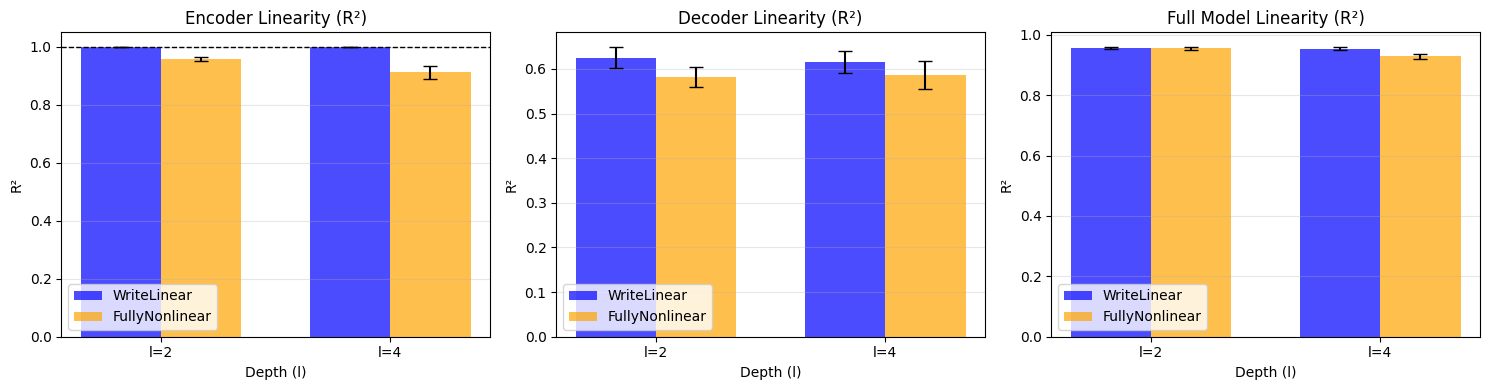

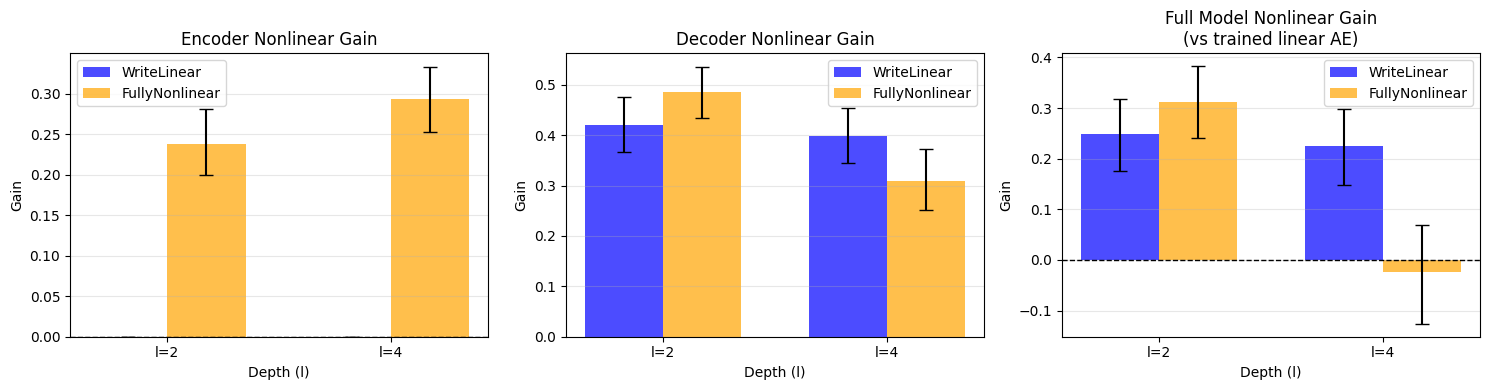

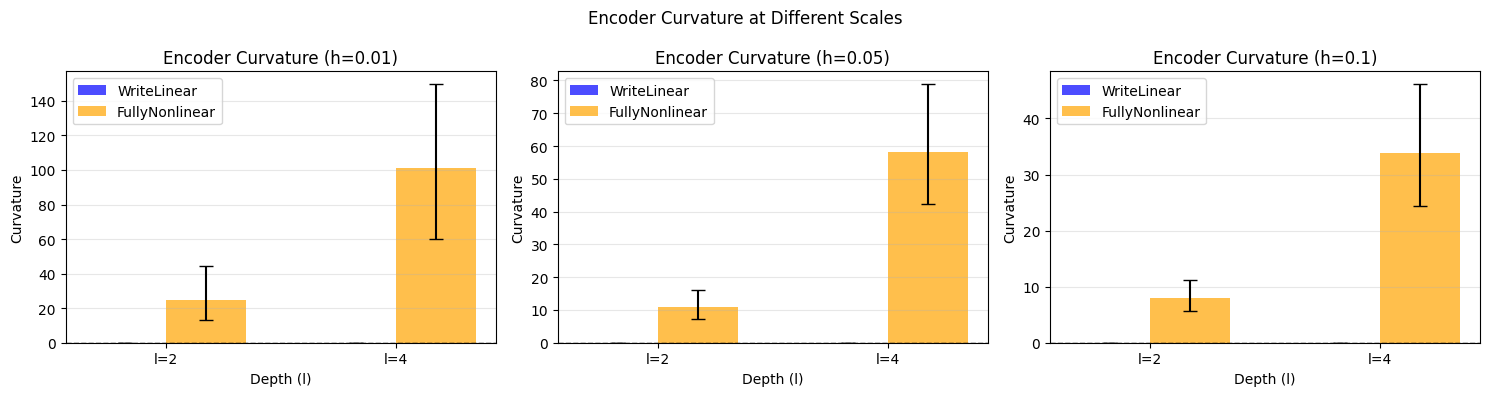


Numeric Summary

Encoder Linearity (R²):
  l=2: WL=1.0000±0.0000, FN=0.9594±0.0459
  l=4: WL=1.0000±0.0000, FN=0.9124±0.1601

Decoder Linearity (R²):
  l=2: WL=0.6254±0.1821, FN=0.5822±0.1777
  l=4: WL=0.6148±0.1753, FN=0.5863±0.2236

Full Model Linearity (R²):
  l=2: WL=0.9556±0.0307, FN=0.9553±0.0335
  l=4: WL=0.9536±0.0359, FN=0.9286±0.0479

Encoder Nonlinear Gain:
  l=2: WL=-0.0000±0.0000, FN=0.2383±0.2842
  l=4: WL=0.0000±0.0000, FN=0.2938±0.2931

Decoder Nonlinear Gain:
  l=2: WL=0.4204±0.3878, FN=0.4848±0.3732
  l=4: WL=0.3983±0.4310, FN=0.3099±0.4482

Full Nonlinear Gain (vs linear AE):
  l=2: WL=0.2492±0.5049, FN=0.3130±0.4983
  l=4: WL=0.2251±0.5510, FN=-0.0247±0.6989

Encoder Curvature by h value:

  h=0.01:
    l=2: WL=0.0001±0.0001, FN=24.6271±119.0284
    l=4: WL=0.0001±0.0001, FN=100.8679±340.3571

  h=0.05:
    l=2: WL=0.0000±0.0000, FN=10.7764±32.6818
    l=4: WL=0.0000±0.0000, FN=58.0823±135.2717

  h=0.1:
    l=2: WL=0.0000±0.0000, FN=7.9901±19.4515
    l=4: WL=0.00

In [18]:
# Linearity Metrics with Bar Graphs + CIs

def get_metric_stats(metric_name):
    """Get means and CIs for a metric across architectures and depths."""
    stats = {'WriteLinear': {}, 'FullyNonlinear': {}}
    for arch in ['WriteLinear', 'FullyNonlinear']:
        for l in l_values:
            vals = [r[metric_name] for r in results[arch][l] if r.get(metric_name) is not None]
            if vals:
                mean = np.mean(vals)
                ci = bootstrap_ci(vals)
                stats[arch][l] = {'mean': mean, 'ci': ci, 'std': np.std(vals)}
    return stats

def get_curvature_stats(h_value):
    """Get curvature stats for a specific h value."""
    stats = {'WriteLinear': {}, 'FullyNonlinear': {}}
    key = f'curvature_h{h_value}'
    for arch in ['WriteLinear', 'FullyNonlinear']:
        for l in l_values:
            vals = [r['encoder_curvature_all'].get(key, 0) for r in results[arch][l]]
            if vals:
                mean = np.mean(vals)
                ci = bootstrap_ci(vals)
                stats[arch][l] = {'mean': mean, 'ci': ci, 'std': np.std(vals)}
    return stats

def plot_metric_comparison(metric_name, title, ylabel, ax, show_baseline=None, stats=None):
    """Plot bar graph with CIs for a metric."""
    if stats is None:
        stats = get_metric_stats(metric_name)
    
    x = np.arange(len(l_values))
    width = 0.35
    
    wl_means = [stats['WriteLinear'][l]['mean'] for l in l_values]
    fn_means = [stats['FullyNonlinear'][l]['mean'] for l in l_values]
    
    wl_errs = np.array([[stats['WriteLinear'][l]['mean'] - stats['WriteLinear'][l]['ci'][0],
                         stats['WriteLinear'][l]['ci'][1] - stats['WriteLinear'][l]['mean']] 
                        for l in l_values]).T
    fn_errs = np.array([[stats['FullyNonlinear'][l]['mean'] - stats['FullyNonlinear'][l]['ci'][0],
                         stats['FullyNonlinear'][l]['ci'][1] - stats['FullyNonlinear'][l]['mean']] 
                        for l in l_values]).T
    
    ax.bar(x - width/2, wl_means, width, yerr=wl_errs, label='WriteLinear', 
           color='blue', alpha=0.7, capsize=5)
    ax.bar(x + width/2, fn_means, width, yerr=fn_errs, label='FullyNonlinear', 
           color='orange', alpha=0.7, capsize=5)
    
    if show_baseline is not None:
        ax.axhline(y=show_baseline, color='black', linestyle='--', linewidth=1)
    
    ax.set_xlabel('Depth (l)')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels([f'l={l}' for l in l_values])
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3, axis='y')

# Plot linearity scores (1x3)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
plot_metric_comparison('encoder_linearity', 'Encoder Linearity (R²)', 'R²', axes[0], show_baseline=1.0)
plot_metric_comparison('decoder_linearity', 'Decoder Linearity (R²)', 'R²', axes[1])
plot_metric_comparison('full_linearity', 'Full Model Linearity (R²)', 'R²', axes[2])
plt.tight_layout()
plt.show()

# Plot nonlinear gains (1x3)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
plot_metric_comparison('encoder_nonlinear_gain', 'Encoder Nonlinear Gain', 'Gain', axes[0], show_baseline=0.0)
plot_metric_comparison('decoder_nonlinear_gain', 'Decoder Nonlinear Gain', 'Gain', axes[1])
plot_metric_comparison('full_nonlinear_gain', 'Full Model Nonlinear Gain\n(vs trained linear AE)', 'Gain', axes[2], show_baseline=0.0)
plt.tight_layout()
plt.show()

# Plot encoder curvature at different h values (1x3)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, h in zip(axes, [0.01, 0.05, 0.1]):
    stats = get_curvature_stats(h)
    plot_metric_comparison(None, f'Encoder Curvature (h={h})', 'Curvature', ax, 
                          show_baseline=0.0, stats=stats)
plt.suptitle('Encoder Curvature at Different Scales', fontsize=12)
plt.tight_layout()
plt.show()

# Print table summary
print("\nNumeric Summary")
print("=" * 80)
metrics = [
    ('encoder_linearity', 'Encoder Linearity (R²)'),
    ('decoder_linearity', 'Decoder Linearity (R²)'),
    ('full_linearity', 'Full Model Linearity (R²)'),
    ('encoder_nonlinear_gain', 'Encoder Nonlinear Gain'),
    ('decoder_nonlinear_gain', 'Decoder Nonlinear Gain'),
    ('full_nonlinear_gain', 'Full Nonlinear Gain (vs linear AE)'),
]

for metric, name in metrics:
    print(f"\n{name}:")
    for l in l_values:
        wl_vals = [r[metric] for r in results['WriteLinear'][l] if r.get(metric) is not None]
        fn_vals = [r[metric] for r in results['FullyNonlinear'][l] if r.get(metric) is not None]
        if wl_vals and fn_vals:
            print(f"  l={l}: WL={np.mean(wl_vals):.4f}±{np.std(wl_vals):.4f}, FN={np.mean(fn_vals):.4f}±{np.std(fn_vals):.4f}")

print("\nEncoder Curvature by h value:")
for h in [0.01, 0.05, 0.1]:
    key = f'curvature_h{h}'
    print(f"\n  h={h}:")
    for l in l_values:
        wl_vals = [r['encoder_curvature_all'].get(key, 0) for r in results['WriteLinear'][l]]
        fn_vals = [r['encoder_curvature_all'].get(key, 0) for r in results['FullyNonlinear'][l]]
        print(f"    l={l}: WL={np.mean(wl_vals):.4f}±{np.std(wl_vals):.4f}, FN={np.mean(fn_vals):.4f}±{np.std(fn_vals):.4f}")

In [19]:
# Decomposition analysis: does encoder + decoder ≈ full?
print("\n" + "=" * 65)
print("DECOMPOSITION ANALYSIS")
print("=" * 65)

print("""
Note: encoder_gain + decoder_gain ≠ full_gain because each uses a different baseline:

  - encoder_nonlinear_gain: (mse_linear_encoder - mse_full) / mse_linear_encoder
    = benefit of nonlinear encoder, holding decoder fixed (nonlinear)

  - decoder_nonlinear_gain: (mse_linear_decoder - mse_full) / mse_linear_decoder
    = benefit of nonlinear decoder, holding encoder fixed (nonlinear)

  - full_nonlinear_gain: (mse_linear_AE - mse_full) / mse_linear_AE
    = benefit of full nonlinear model vs trained linear autoencoder

These are individually meaningful but don't compose additively. The full_nonlinear_gain
is the most interpretable: how much does having ReLUs help vs a purely linear AE?
""")

print("-" * 65)
print("Comparison of gains:")
print("-" * 65)

for l in l_values:
    print(f"\nl={l}:")
    for arch in ['WriteLinear', 'FullyNonlinear']:
        enc_gains = [r['encoder_nonlinear_gain'] for r in results[arch][l]]
        dec_gains = [r['decoder_nonlinear_gain'] for r in results[arch][l]]
        full_gains = [r['full_nonlinear_gain'] for r in results[arch][l] if r['full_nonlinear_gain'] is not None]
        
        print(f"  {arch}:")
        print(f"    encoder_gain = {np.mean(enc_gains):.4f} ± {np.std(enc_gains):.4f}")
        print(f"    decoder_gain = {np.mean(dec_gains):.4f} ± {np.std(dec_gains):.4f}")
        if len(full_gains) > 0:
            print(f"    full_gain    = {np.mean(full_gains):.4f} ± {np.std(full_gains):.4f}  (vs linear AE)")


DECOMPOSITION ANALYSIS

Note: encoder_gain + decoder_gain ≠ full_gain because each uses a different baseline:

  - encoder_nonlinear_gain: (mse_linear_encoder - mse_full) / mse_linear_encoder
    = benefit of nonlinear encoder, holding decoder fixed (nonlinear)

  - decoder_nonlinear_gain: (mse_linear_decoder - mse_full) / mse_linear_decoder
    = benefit of nonlinear decoder, holding encoder fixed (nonlinear)

  - full_nonlinear_gain: (mse_linear_AE - mse_full) / mse_linear_AE
    = benefit of full nonlinear model vs trained linear autoencoder

These are individually meaningful but don't compose additively. The full_nonlinear_gain
is the most interpretable: how much does having ReLUs help vs a purely linear AE?

-----------------------------------------------------------------
Comparison of gains:
-----------------------------------------------------------------

l=2:
  WriteLinear:
    encoder_gain = -0.0000 ± 0.0000
    decoder_gain = 0.4204 ± 0.3878
    full_gain    = 0.2492 ± 0.5

### 3.3 Gradient Analysis

How does the latent magnitude and velocity (||dz/dt||) change along feature trajectories?

- **Latent magnitude**: ||z(t·eᵢ)|| as a function of input magnitude t
- **Velocity**: ||dz/dt|| = rate of change of latent position along trajectory

Linear encoder: constant velocity. Nonlinear: variable velocity (acceleration/deceleration).

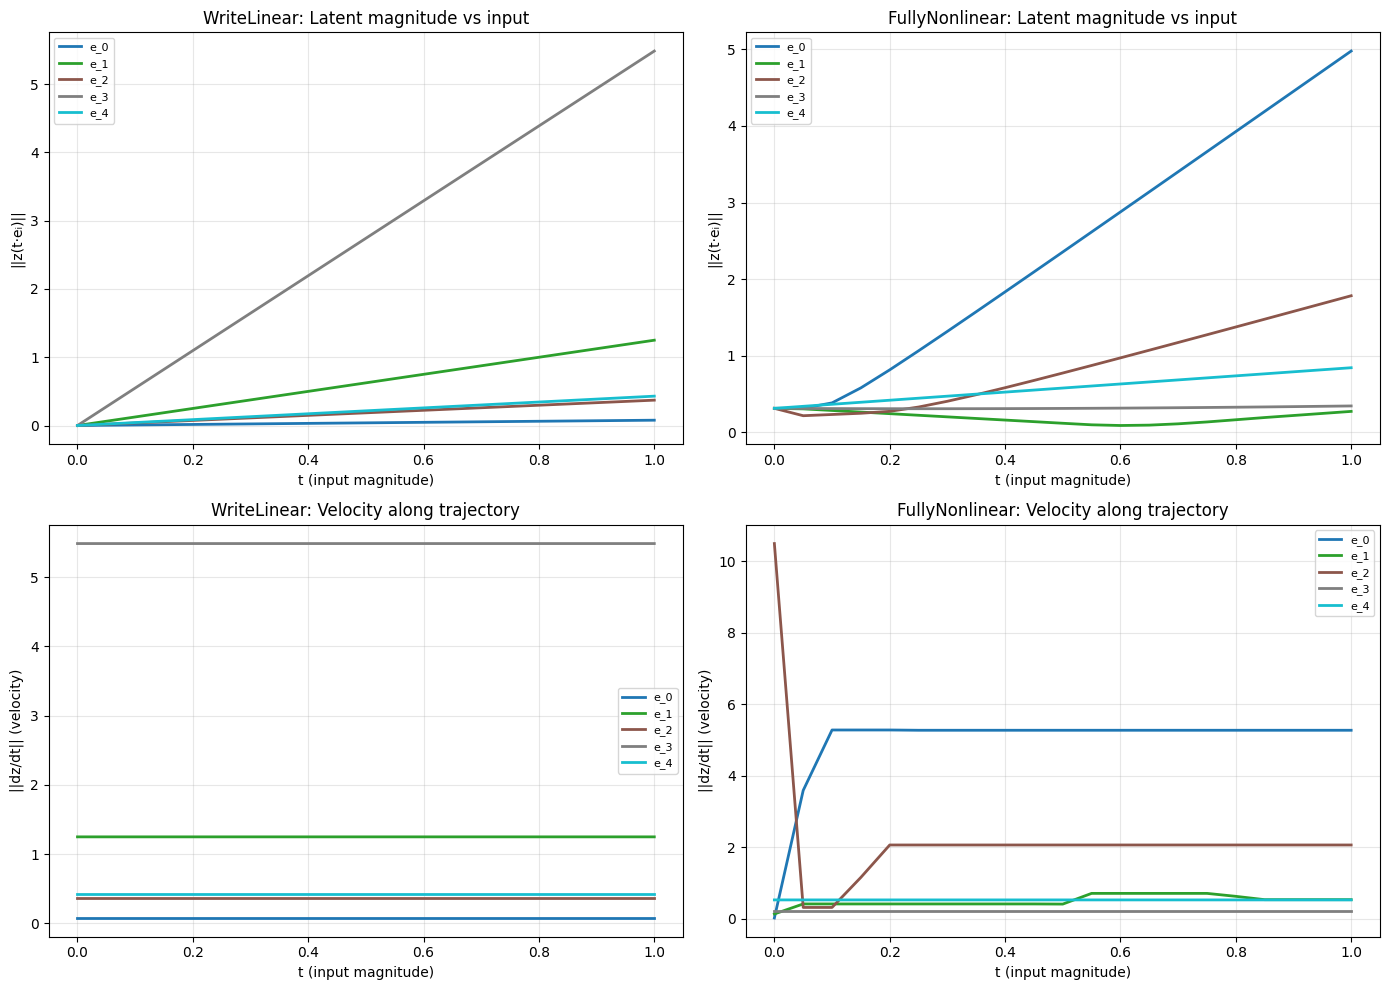

WriteLinear: Velocities should be constant (linear encoder → straight trajectories)
FullyNonlinear: Velocities may vary, indicating acceleration/deceleration through ReLU regions


In [20]:
# Latent Magnitude and Velocity along Feature Trajectories

def compute_trajectory_velocity(model, n_points=21):
    """
    Compute latent magnitude and velocity along feature trajectories.
    
    Velocity is computed as ||z(t+dt) - z(t)|| / dt using finite differences.
    """
    model.eval()
    t_values = np.linspace(0, 1, n_points)
    dt = t_values[1] - t_values[0]
    
    magnitudes = {}
    velocities = {}
    
    with torch.no_grad():
        for i in range(model.n):
            # Create trajectory points
            traj = torch.zeros(n_points, model.n, device=device)
            traj[:, i] = torch.tensor(t_values, device=device)
            
            # Encode all points
            z_traj = model.encode(traj)
            
            # Magnitudes
            mags = z_traj.norm(dim=1).cpu().numpy()
            magnitudes[i] = mags
            
            # Velocities (finite difference)
            vels = np.zeros(n_points)
            vels[:-1] = np.linalg.norm(np.diff(z_traj.cpu().numpy(), axis=0), axis=1) / dt
            vels[-1] = vels[-2]  # Extrapolate last point
            velocities[i] = vels
    
    return magnitudes, velocities, t_values

# Visualize for best models at l=2
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for col, arch in enumerate(['WriteLinear', 'FullyNonlinear']):
    best_run = min(results[arch][2], key=lambda r: r['test_loss'])
    model = best_run['model']
    
    mags, vels, t_vals = compute_trajectory_velocity(model)
    colors = plt.cm.tab10(np.linspace(0, 1, n))
    
    # Top: Magnitude ||z|| vs t
    ax = axes[0, col]
    for i in range(n):
        ax.plot(t_vals, mags[i], color=colors[i], linewidth=2, label=f'e_{i}')
    ax.set_xlabel('t (input magnitude)')
    ax.set_ylabel('||z(t·eᵢ)||')
    ax.set_title(f'{arch}: Latent magnitude vs input')
    ax.legend(loc='best', fontsize=8)
    ax.grid(True, alpha=0.3)
    
    # Bottom: Velocity ||dz/dt|| vs t
    ax = axes[1, col]
    for i in range(n):
        ax.plot(t_vals, vels[i], color=colors[i], linewidth=2, label=f'e_{i}')
    ax.set_xlabel('t (input magnitude)')
    ax.set_ylabel('||dz/dt|| (velocity)')
    ax.set_title(f'{arch}: Velocity along trajectory')
    ax.legend(loc='best', fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("WriteLinear: Velocities should be constant (linear encoder → straight trajectories)")
print("FullyNonlinear: Velocities may vary, indicating acceleration/deceleration through ReLU regions")

In [21]:
# Velocity statistics
print("Mean Velocity by Feature (l=2)")
print("=" * 60)

for arch in ['WriteLinear', 'FullyNonlinear']:
    best_run = min(results[arch][2], key=lambda r: r['test_loss'])
    model = best_run['model']
    _, vels, _ = compute_trajectory_velocity(model)
    
    print(f"\n{arch}:")
    for i in range(n):
        mean_vel = np.mean(vels[i])
        std_vel = np.std(vels[i])
        cv = std_vel / mean_vel if mean_vel > 0 else 0  # Coefficient of variation
        print(f"  Feature {i}: mean={mean_vel:.4f}, std={std_vel:.4f}, CV={cv:.2f}")
    
print("\nCV (coefficient of variation) measures velocity variability:")
print("  CV ≈ 0 → constant velocity (linear)")  
print("  CV > 0 → variable velocity (nonlinear)")

Mean Velocity by Feature (l=2)

WriteLinear:
  Feature 0: mean=0.0777, std=0.0000, CV=0.00
  Feature 1: mean=1.2496, std=0.0000, CV=0.00
  Feature 2: mean=0.3713, std=0.0000, CV=0.00
  Feature 3: mean=5.4857, std=0.0000, CV=0.00
  Feature 4: mean=0.4299, std=0.0000, CV=0.00

FullyNonlinear:
  Feature 0: mean=4.9436, std=1.1566, CV=0.23
  Feature 1: mean=0.5073, std=0.1461, CV=0.29
  Feature 2: mean=2.2577, std=1.9165, CV=0.85
  Feature 3: mean=0.2087, std=0.0000, CV=0.00
  Feature 4: mean=0.5305, std=0.0000, CV=0.00

CV (coefficient of variation) measures velocity variability:
  CV ≈ 0 → constant velocity (linear)
  CV > 0 → variable velocity (nonlinear)


## 4. Other Metrics

Additional metrics for understanding model behavior. Future additions may include:
- Activation sparsity
- Input robustness (noise sensitivity)
- Non-sparsity robustness (co-occurrence handling)

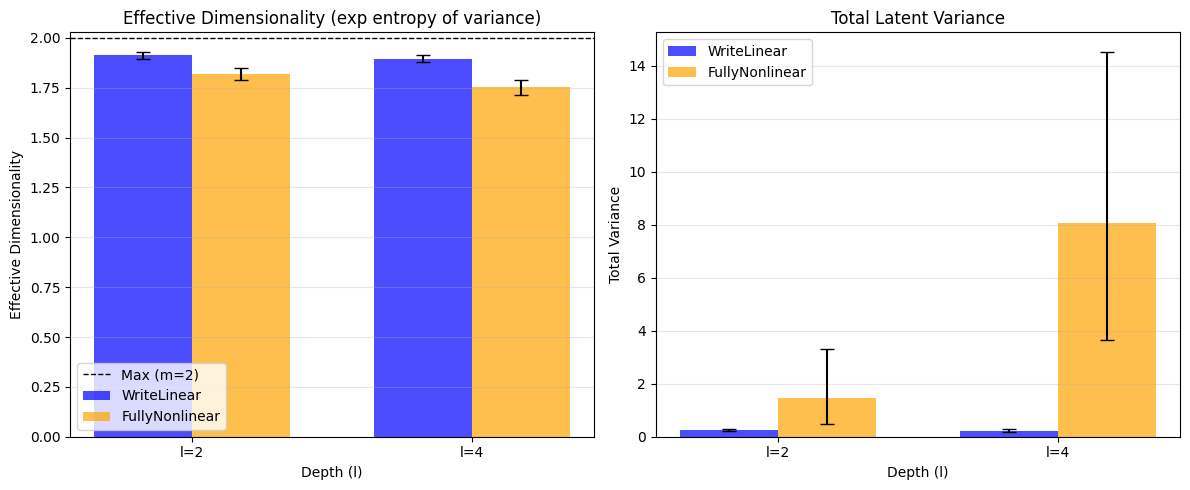


Numeric Summary

l=2:
  WriteLinear:
    Effective dim: 1.912 ± 0.136 (max=2)
    Total variance: 0.2413 ± 0.2922
  FullyNonlinear:
    Effective dim: 1.819 ± 0.225 (max=2)
    Total variance: 1.4539 ± 11.8693

l=4:
  WriteLinear:
    Effective dim: 1.895 ± 0.132 (max=2)
    Total variance: 0.2232 ± 0.3448
  FullyNonlinear:
    Effective dim: 1.752 ± 0.287 (max=2)
    Total variance: 8.0541 ± 39.8860

Future metrics to add:
  - Activation sparsity: how often are ReLUs inactive?
  - Input robustness: MSE degradation under input noise
  - Co-occurrence robustness: MSE with non-sparse (multi-feature) inputs


In [22]:
# Latent Utilization with Bar Graphs + CIs

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Effective dimensionality
ax = axes[0]
x = np.arange(len(l_values))
width = 0.35

wl_means, wl_errs = [], []
fn_means, fn_errs = [], []

for l in l_values:
    wl_vals = [r['latent_util']['effective_dim'] for r in results['WriteLinear'][l]]
    fn_vals = [r['latent_util']['effective_dim'] for r in results['FullyNonlinear'][l]]
    
    wl_means.append(np.mean(wl_vals))
    fn_means.append(np.mean(fn_vals))
    
    wl_ci = bootstrap_ci(wl_vals)
    fn_ci = bootstrap_ci(fn_vals)
    wl_errs.append([wl_means[-1] - wl_ci[0], wl_ci[1] - wl_means[-1]])
    fn_errs.append([fn_means[-1] - fn_ci[0], fn_ci[1] - fn_means[-1]])

wl_errs = np.array(wl_errs).T
fn_errs = np.array(fn_errs).T

ax.bar(x - width/2, wl_means, width, yerr=wl_errs, label='WriteLinear', 
       color='blue', alpha=0.7, capsize=5)
ax.bar(x + width/2, fn_means, width, yerr=fn_errs, label='FullyNonlinear', 
       color='orange', alpha=0.7, capsize=5)
ax.axhline(y=m, color='black', linestyle='--', linewidth=1, label=f'Max (m={m})')
ax.set_xlabel('Depth (l)')
ax.set_ylabel('Effective Dimensionality')
ax.set_title('Effective Dimensionality (exp entropy of variance)')
ax.set_xticks(x)
ax.set_xticklabels([f'l={l}' for l in l_values])
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Total variance
ax = axes[1]
wl_means, wl_errs = [], []
fn_means, fn_errs = [], []

for l in l_values:
    wl_vals = [r['latent_util']['total_variance'] for r in results['WriteLinear'][l]]
    fn_vals = [r['latent_util']['total_variance'] for r in results['FullyNonlinear'][l]]
    
    wl_means.append(np.mean(wl_vals))
    fn_means.append(np.mean(fn_vals))
    
    wl_ci = bootstrap_ci(wl_vals)
    fn_ci = bootstrap_ci(fn_vals)
    wl_errs.append([wl_means[-1] - wl_ci[0], wl_ci[1] - wl_means[-1]])
    fn_errs.append([fn_means[-1] - fn_ci[0], fn_ci[1] - fn_means[-1]])

wl_errs = np.array(wl_errs).T
fn_errs = np.array(fn_errs).T

ax.bar(x - width/2, wl_means, width, yerr=wl_errs, label='WriteLinear', 
       color='blue', alpha=0.7, capsize=5)
ax.bar(x + width/2, fn_means, width, yerr=fn_errs, label='FullyNonlinear', 
       color='orange', alpha=0.7, capsize=5)
ax.set_xlabel('Depth (l)')
ax.set_ylabel('Total Variance')
ax.set_title('Total Latent Variance')
ax.set_xticks(x)
ax.set_xticklabels([f'l={l}' for l in l_values])
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Print numeric summary
print("\nNumeric Summary")
print("=" * 60)
for l in l_values:
    print(f"\nl={l}:")
    for arch in ['WriteLinear', 'FullyNonlinear']:
        eff_dims = [r['latent_util']['effective_dim'] for r in results[arch][l]]
        total_vars = [r['latent_util']['total_variance'] for r in results[arch][l]]
        
        print(f"  {arch}:")
        print(f"    Effective dim: {np.mean(eff_dims):.3f} ± {np.std(eff_dims):.3f} (max={m})")
        print(f"    Total variance: {np.mean(total_vars):.4f} ± {np.std(total_vars):.4f}")

print("\nFuture metrics to add:")
print("  - Activation sparsity: how often are ReLUs inactive?")
print("  - Input robustness: MSE degradation under input noise")
print("  - Co-occurrence robustness: MSE with non-sparse (multi-feature) inputs")

## 5. Summary

Key findings from the WriteLinear vs FullyNonlinear comparison.

In [23]:
from scipy import stats

print("=" * 70)
print("SUMMARY: WriteLinear vs FullyNonlinear")
print("=" * 70)

print(f"\nConfiguration: n={n}, m={m}, S={S}, {n_steps} steps, {n_seeds} seeds")
print(f"Linear AE baseline MSE: {mse_linear_ae:.6f}")

# 1. Primary Results with Statistical Tests
print("\n" + "=" * 70)
print("1. PRIMARY RESULTS: Test Loss")
print("=" * 70)

for l in l_values:
    wl_losses = [r['test_loss'] for r in results['WriteLinear'][l]]
    fn_losses = [r['test_loss'] for r in results['FullyNonlinear'][l]]
    
    print(f"\nl={l}:")
    print(f"  WriteLinear:     {np.mean(wl_losses):.6f} ± {np.std(wl_losses):.6f} (best: {np.min(wl_losses):.6f})")
    print(f"  FullyNonlinear:  {np.mean(fn_losses):.6f} ± {np.std(fn_losses):.6f} (best: {np.min(fn_losses):.6f})")
    
    frontier_diff = (np.min(wl_losses) - np.min(fn_losses)) / np.min(fn_losses) * 100
    mean_diff = (np.mean(wl_losses) - np.mean(fn_losses)) / np.mean(fn_losses) * 100
    print(f"  Mean diff: {mean_diff:+.1f}%, Frontier diff: {frontier_diff:+.1f}%")
    
    # Mann-Whitney U test
    stat, p_value = stats.mannwhitneyu(wl_losses, fn_losses, alternative='two-sided')
    print(f"  Mann-Whitney U: p = {p_value:.4f}", end="")
    if p_value < 0.05:
        better = 'WriteLinear' if np.mean(wl_losses) < np.mean(fn_losses) else 'FullyNonlinear'
        print(f" ** {better} significantly better")
    else:
        print(" (not significant)")

# Parameter-matched comparison
print("\nParameter-Matched (WriteLinear l=3 vs FullyNonlinear l=2):")
wl3_losses = [r['test_loss'] for r in results['WriteLinear'][3]]
fn2_losses = [r['test_loss'] for r in results['FullyNonlinear'][2]]
print(f"  WriteLinear(l=3):    {np.mean(wl3_losses):.6f} ± {np.std(wl3_losses):.6f}")
print(f"  FullyNonlinear(l=2): {np.mean(fn2_losses):.6f} ± {np.std(fn2_losses):.6f}")
stat, p_value = stats.mannwhitneyu(wl3_losses, fn2_losses, alternative='two-sided')
print(f"  Mann-Whitney U: p = {p_value:.4f}", end="")
if p_value < 0.05:
    better = 'WriteLinear(l=3)' if np.mean(wl3_losses) < np.mean(fn2_losses) else 'FullyNonlinear(l=2)'
    print(f" ** {better} significantly better")
else:
    print(" (not significant)")

# 2. Nonlinear Gains
print("\n" + "=" * 70)
print("2. NONLINEAR GAINS (vs Linear AE)")
print("=" * 70)

for l in l_values:
    wl_full = [r['full_nonlinear_gain'] for r in results['WriteLinear'][l] if r.get('full_nonlinear_gain') is not None]
    fn_full = [r['full_nonlinear_gain'] for r in results['FullyNonlinear'][l] if r.get('full_nonlinear_gain') is not None]
    
    print(f"\nl={l}:")
    if wl_full:
        print(f"  WriteLinear:     {np.mean(wl_full):.4f} ± {np.std(wl_full):.4f}")
    if fn_full:
        print(f"  FullyNonlinear:  {np.mean(fn_full):.4f} ± {np.std(fn_full):.4f}")
    
    if wl_full and fn_full:
        stat, p_value = stats.mannwhitneyu(wl_full, fn_full, alternative='two-sided')
        print(f"  Mann-Whitney U: p = {p_value:.4f}", end="")
        if p_value < 0.05:
            better = 'WriteLinear' if np.mean(wl_full) > np.mean(fn_full) else 'FullyNonlinear'
            print(f" ** {better} significantly higher gain")
        else:
            print(" (not significant)")

# 3. Encoder Nonlinearity
print("\n" + "=" * 70)
print("3. ENCODER NONLINEARITY")
print("=" * 70)

for l in l_values:
    wl_arc = [r['arc_chord_mean'] for r in results['WriteLinear'][l]]
    fn_arc = [r['arc_chord_mean'] for r in results['FullyNonlinear'][l]]
    wl_lin = [r['encoder_linearity'] for r in results['WriteLinear'][l]]
    fn_lin = [r['encoder_linearity'] for r in results['FullyNonlinear'][l]]
    
    print(f"\nl={l}:")
    print(f"  Arc/Chord:   WL={np.mean(wl_arc):.6f}±{np.std(wl_arc):.6f}, FN={np.mean(fn_arc):.4f}±{np.std(fn_arc):.4f}")
    print(f"  Enc Linear:  WL={np.mean(wl_lin):.6f}±{np.std(wl_lin):.6f}, FN={np.mean(fn_lin):.4f}±{np.std(fn_lin):.4f}")

# 4. Convergence Speed
print("\n" + "=" * 70)
print("4. CONVERGENCE SPEED")
print("=" * 70)

for l in l_values:
    wl_speed = [r['convergence_speed'] for r in results['WriteLinear'][l]]
    fn_speed = [r['convergence_speed'] for r in results['FullyNonlinear'][l]]
    
    print(f"\nl={l}:")
    print(f"  WriteLinear:     {np.mean(wl_speed):.0f} ± {np.std(wl_speed):.0f} steps")
    print(f"  FullyNonlinear:  {np.mean(fn_speed):.0f} ± {np.std(fn_speed):.0f} steps")
    print(f"  Ratio: {np.mean(wl_speed)/np.mean(fn_speed):.2f}x")
    
    stat, p_value = stats.mannwhitneyu(wl_speed, fn_speed, alternative='two-sided')
    print(f"  Mann-Whitney U: p = {p_value:.4f}", end="")
    if p_value < 0.05:
        faster = 'WriteLinear' if np.mean(wl_speed) < np.mean(fn_speed) else 'FullyNonlinear'
        print(f" ** {faster} converges significantly faster")
    else:
        print(" (not significant)")

# 5. Sanity Checks
print("\n" + "=" * 70)
print("5. SANITY CHECKS")
print("=" * 70)

all_wl_arc = [r['arc_chord_mean'] for l in l_values for r in results['WriteLinear'][l]]
max_dev = max(abs(r - 1.0) for r in all_wl_arc)
print(f"\nWriteLinear arc/chord max deviation from 1.0: {max_dev:.2e}")
print("  ✓ Confirmed linear encoder" if max_dev < 1e-6 else "  ⚠ Unexpected deviation")

all_wl_lin = [r['encoder_linearity'] for l in l_values for r in results['WriteLinear'][l]]
min_lin = min(all_wl_lin)
print(f"\nWriteLinear encoder linearity minimum: {min_lin:.6f}")
print("  ✓ Confirmed R²=1.0" if min_lin > 0.9999 else "  ⚠ Unexpected deviation")

# 6. Interpretation
print("\n" + "=" * 70)
print("6. INTERPRETATION")
print("=" * 70)

all_diffs = []
for l in l_values:
    wl_best = np.min([r['test_loss'] for r in results['WriteLinear'][l]])
    fn_best = np.min([r['test_loss'] for r in results['FullyNonlinear'][l]])
    all_diffs.append((wl_best - fn_best) / fn_best * 100)

avg_frontier_diff = np.mean(all_diffs)

if abs(avg_frontier_diff) < 10:
    print(f"\nAt the frontier, WriteLinear is within {abs(avg_frontier_diff):.1f}% of FullyNonlinear.")
    print("This suggests 'write linear + read nonlinear' is competitive.")
elif avg_frontier_diff > 10:
    print(f"\nWriteLinear is {avg_frontier_diff:.1f}% worse at the frontier.")
    print("Encoder nonlinearity appears to provide measurable benefits.")
else:
    print(f"\nWriteLinear is {-avg_frontier_diff:.1f}% better at the frontier.")
    print("Linear encoder may have optimization advantages.")

# Effect sizes (Cohen's d)
print("\nEffect Sizes (Cohen's d for test loss):")
for l in l_values:
    wl_losses = [r['test_loss'] for r in results['WriteLinear'][l]]
    fn_losses = [r['test_loss'] for r in results['FullyNonlinear'][l]]
    
    pooled_std = np.sqrt((np.var(wl_losses) + np.var(fn_losses)) / 2)
    cohens_d = (np.mean(wl_losses) - np.mean(fn_losses)) / pooled_std if pooled_std > 0 else 0
    
    effect_size = "negligible" if abs(cohens_d) < 0.2 else "small" if abs(cohens_d) < 0.5 else "medium" if abs(cohens_d) < 0.8 else "large"
    print(f"  l={l}: d = {cohens_d:.3f} ({effect_size})")

print(f"\n{'='*70}")
print(f"Analysis complete. Results saved to {results_dir}/")
print(f"{'='*70}")

SUMMARY: WriteLinear vs FullyNonlinear

Configuration: n=5, m=2, S=0.9, 20000 steps, 200 seeds
Linear AE baseline MSE: 0.014272

1. PRIMARY RESULTS: Test Loss

l=2:
  WriteLinear:     0.010678 ± 0.007205 (best: 0.002319)
  FullyNonlinear:  0.009783 ± 0.007143 (best: 0.001958)
  Mean diff: +9.1%, Frontier diff: +18.4%
  Mann-Whitney U: p = 0.0042 ** FullyNonlinear significantly better

l=4:
  WriteLinear:     0.011127 ± 0.007882 (best: 0.002192)
  FullyNonlinear:  0.014438 ± 0.009935 (best: 0.001963)
  Mean diff: -22.9%, Frontier diff: +11.6%
  Mann-Whitney U: p = 0.0017 ** WriteLinear significantly better

Parameter-Matched (WriteLinear l=3 vs FullyNonlinear l=2):
  WriteLinear(l=3):    0.010480 ± 0.007603
  FullyNonlinear(l=2): 0.009783 ± 0.007143
  Mann-Whitney U: p = 0.0428 ** FullyNonlinear(l=2) significantly better

2. NONLINEAR GAINS (vs Linear AE)

l=2:
  WriteLinear:     0.2492 ± 0.5049
  FullyNonlinear:  0.3130 ± 0.4983
  Mann-Whitney U: p = 0.0614 (not significant)

l=4:
  Wr